In [1]:
import sys
import os
sys.path.append(os.path.dirname(os.getcwd()))

In [2]:
notebook = "real4_Concrete_init_temp5"

In [3]:
from ucimlrepo import fetch_ucirepo
import numpy as np
  
# fetch dataset 
concrete = fetch_ucirepo(id=165) 
  
# data (as pandas dataframes) 
X = concrete.data.features 
y = concrete.data.targets 

In [4]:
X = X.values.astype(float)
y = np.array(y).reshape(-1)

In [5]:
ndpost = 10000
nskip = 0
n_trees = 100

In [ ]:
from experiment_init import run_parallel_experiments

# Run 5 parallel experiments
results = run_parallel_experiments(X, y, ndpost, nskip, n_trees, notebook, 
                                   temperature=5.0,
                                   n_runs=5, n_jobs=-2, store_preds=True, 
                                   n_test_points=100, # Store all test points if not specified
                                   n_chains=4)

In [6]:
import numpy as np

experiment_results = np.load(f'store/{notebook}.npz', allow_pickle=True)

default_data = experiment_results['default'].item()
mtmh_data = experiment_results['mtmh'].item()
metadata = experiment_results['metadata'].item()

n_runs = metadata['n_runs']

# Trace Plot

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_moves_and_pca(
    accepted_moves_logmh, preds, threshold=1, agg_method='min', n_components=5, chain_id=0
):
    """
    Plot exp(log_mh) (min or median per iteration) for each move and PCA 1st component.
    Args:
        accepted_moves_logmh: shape [n_runs, n_chains, ...]
        preds: shape [n_runs, n_chains, n_test_points, n_iter]
        threshold: float, max value for exp(log_mh) to plot (default 1)
        agg_method: 'min' or 'median' for log_mh aggregation per iteration
        n_components: int, number of PCA components
        chain_id: int, which chain to use
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.decomposition import PCA
    n_runs = accepted_moves_logmh.shape[0]
    # 1. Summarize all unique moves across all runs and iterations
    all_moves_set = set()
    for run_id in range(n_runs):
        moves_per_iter = accepted_moves_logmh[run_id, chain_id]
        for moves in moves_per_iter:
            if len(moves) == 0:
                continue
            move_keys = [m[0] for m in moves]
            all_moves_set.update(move_keys)
    all_moves = sorted(list(all_moves_set))  # Ensure consistent order
    # 2. Define colors for each move
    colors = plt.cm.tab10(np.linspace(0, 1, len(all_moves)))
    move2color = {m: colors[i] for i, m in enumerate(all_moves)}
    # 3. Plotting
    for run_id in range(n_runs):
        moves_per_iter = accepted_moves_logmh[run_id, chain_id]
        iters = []
        log_mh_vals = []
        move_names = []
        for i, moves in enumerate(moves_per_iter):
            if len(moves) == 0:
                continue
            move_keys = [m[0] for m in moves]
            log_mhs = [m[1] for m in moves]
            if agg_method == 'min':
                idx = np.argmin(log_mhs)
                agg_val = log_mhs[idx]
                move_name = move_keys[idx]
            elif agg_method == 'median':
                agg_val = np.median(log_mhs)
                move_name = move_keys[0]  # representative
            else:
                raise ValueError("agg_method must be 'min' or 'median'")
            iters.append(i)
            log_mh_vals.append(agg_val)
            move_names.append(move_name)
        # PCA on predictions
        chain_preds = preds[run_id, chain_id].T
        chain_preds_centered = chain_preds - np.mean(chain_preds, axis=0)
        pca = PCA(n_components=n_components)
        chain_preds_pca = pca.fit_transform(chain_preds_centered)
        pc1 = chain_preds_pca[:, 0]
        fig, ax1 = plt.subplots(figsize=(12, 5))
        for m in all_moves:
            idxs = [i for i, mv in enumerate(move_names) if mv == m]
            filtered = [(iters[i], min(np.exp(log_mh_vals[i]), 1)) for i in idxs if min(np.exp(log_mh_vals[i]), 1) <= threshold]
            if not filtered:
                continue
            x_vals, y_vals = zip(*filtered)
            ax1.scatter(x_vals, y_vals, color=move2color[m], label=m, s=18)
        ax1.set_xlabel('Iteration')
        ax1.set_ylabel(f'exp(log_mh) ({agg_method} per iteration)')
        ax1.legend(loc='upper left')
        ax1.grid(alpha=0.3)
        ax2 = ax1.twinx()
        ax2.plot(range(len(pc1)), pc1, color='black', label='PCA 1st component', linewidth=1.5, alpha=0.7)
        ax2.set_ylabel('PCA 1st component')
        ax2.legend(loc='upper right')
        plt.title(f'Run {run_id}, Chain {chain_id}: {agg_method} exp(log_mh) per iteration & PCA1')
        plt.tight_layout()
        plt.show()

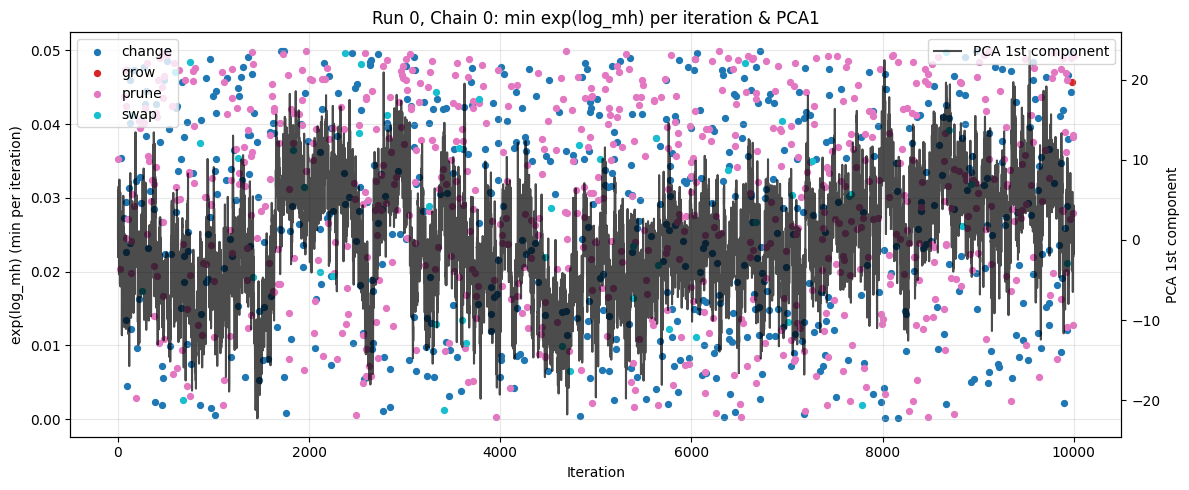

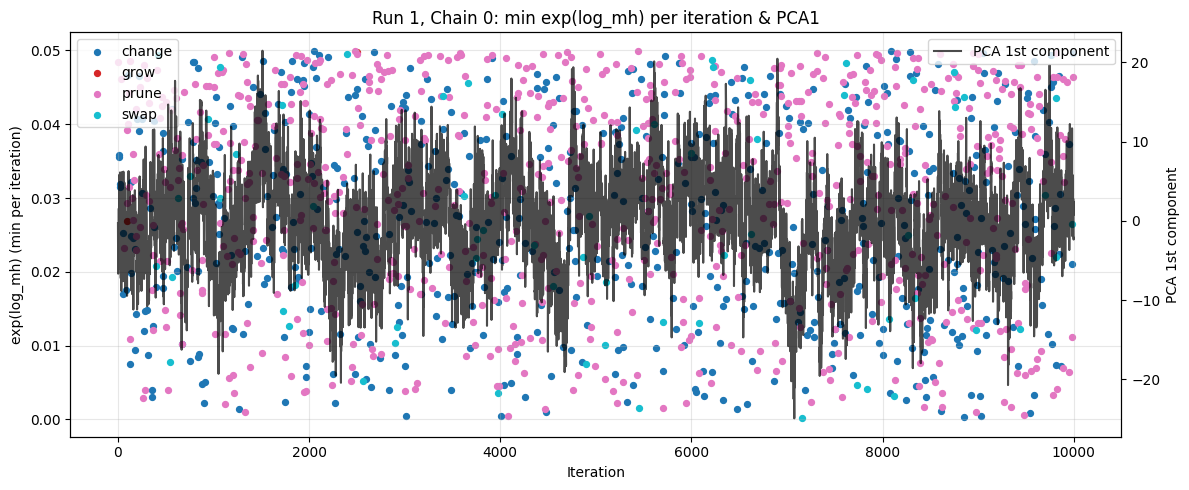

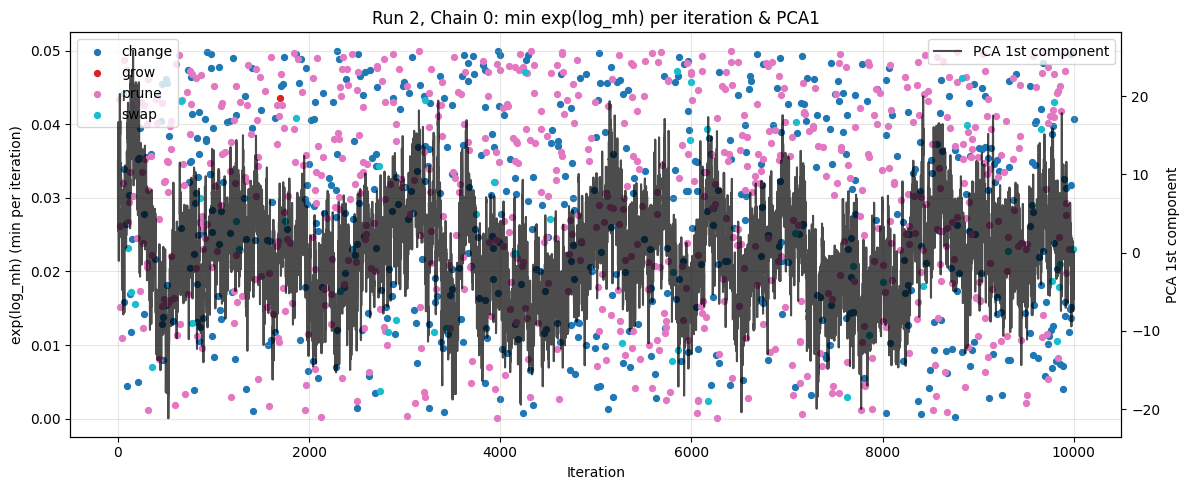

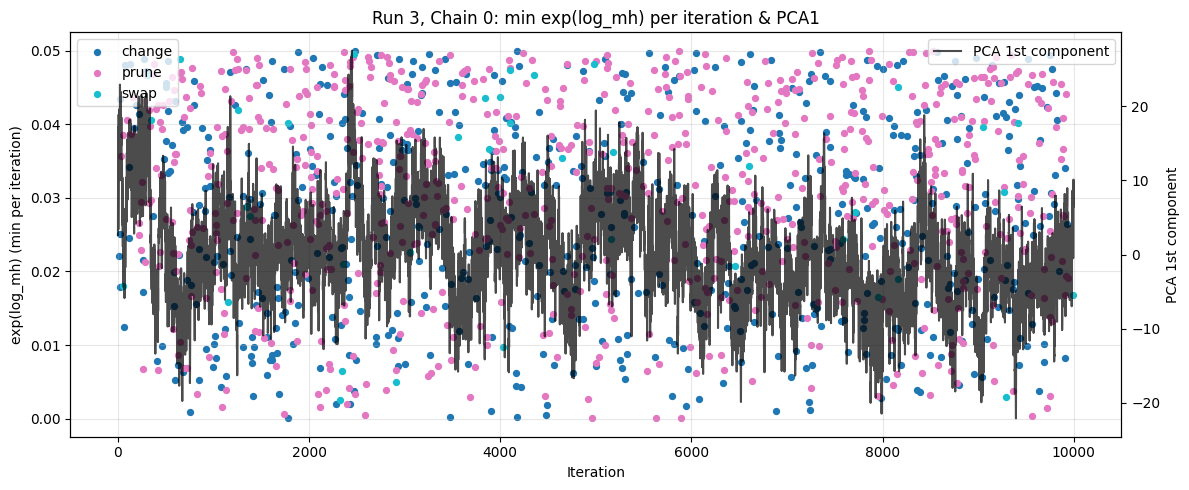

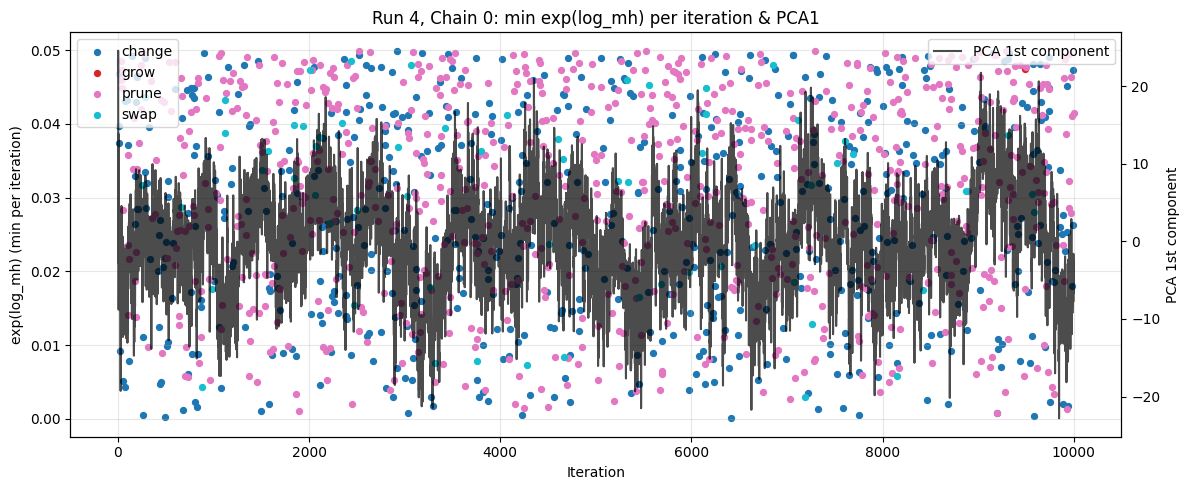

In [8]:
accepted_moves_logmh = default_data['accepted_moves_logmh']
preds = default_data['preds']

plot_moves_and_pca(
    accepted_moves_logmh,
    preds,
    threshold=0.05,
    agg_method='min',
    n_components=5,
    chain_id=0
)

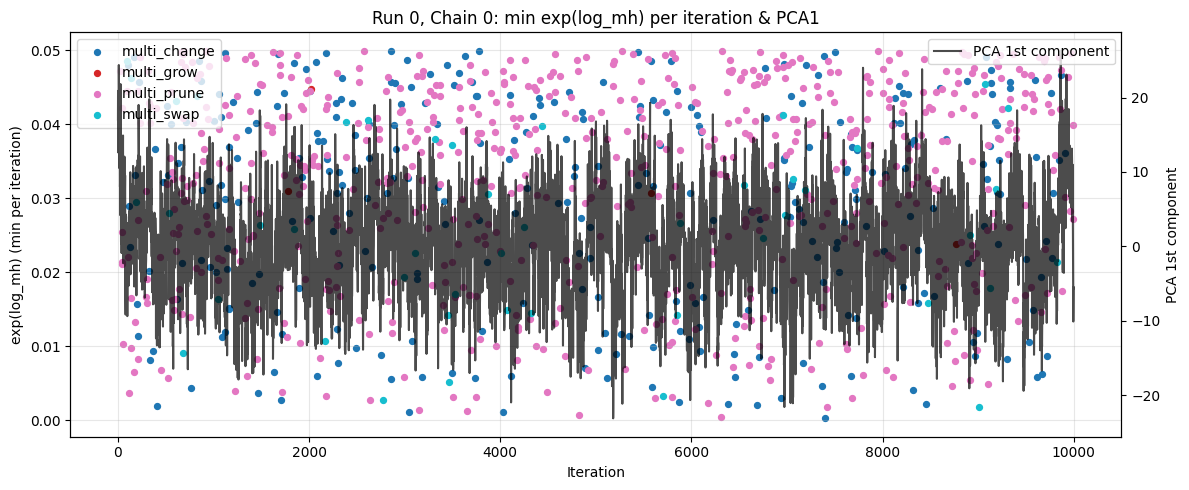

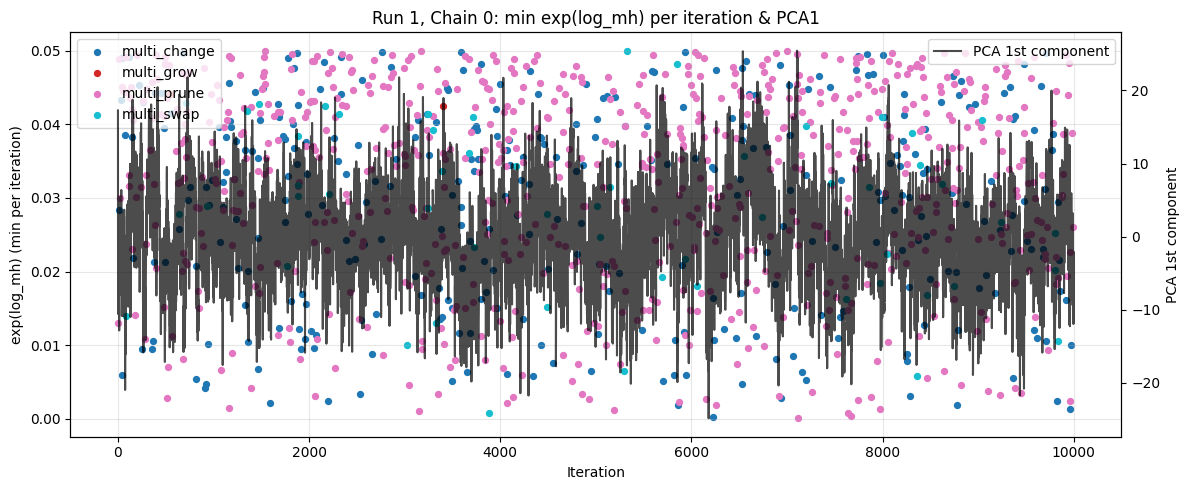

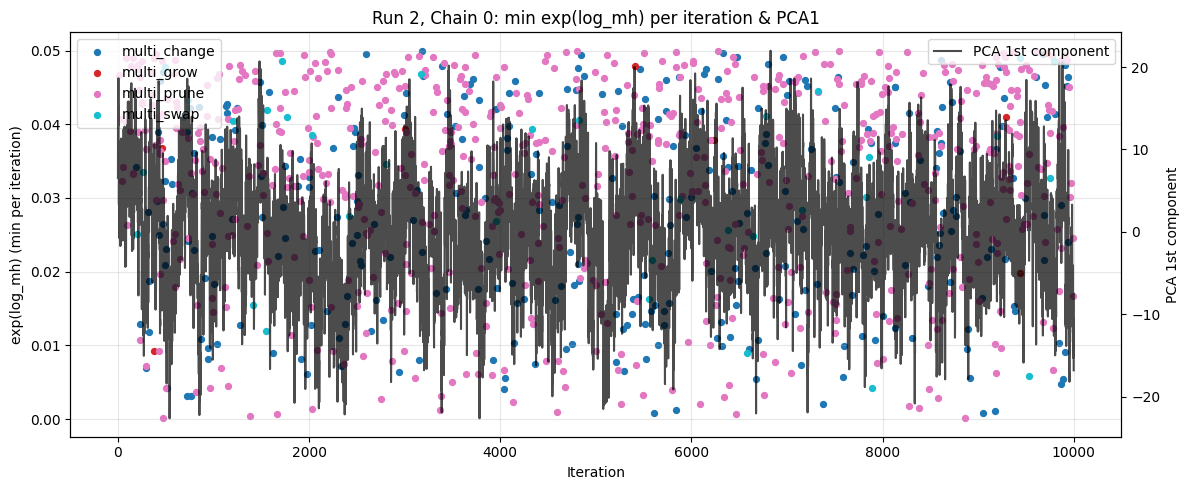

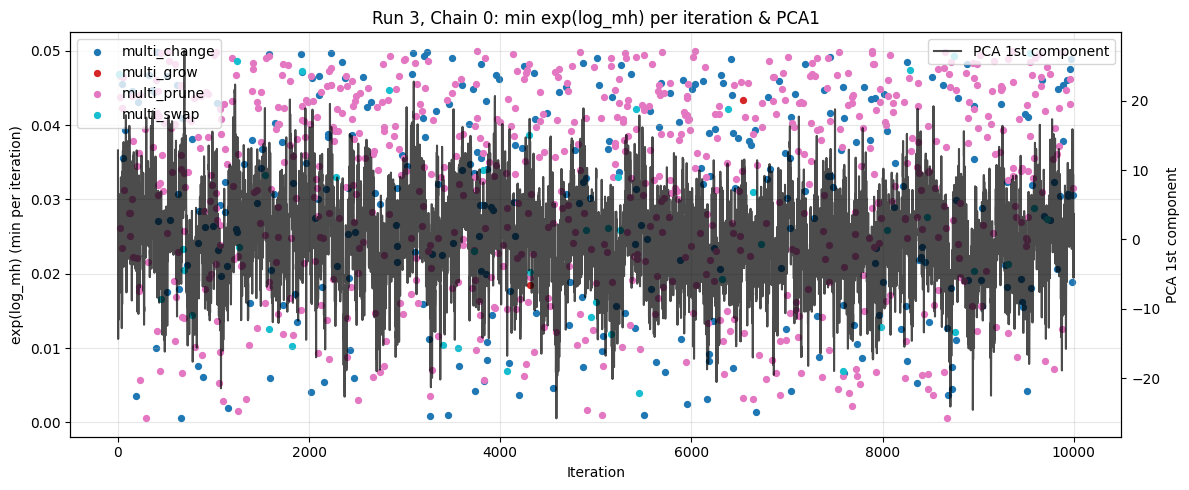

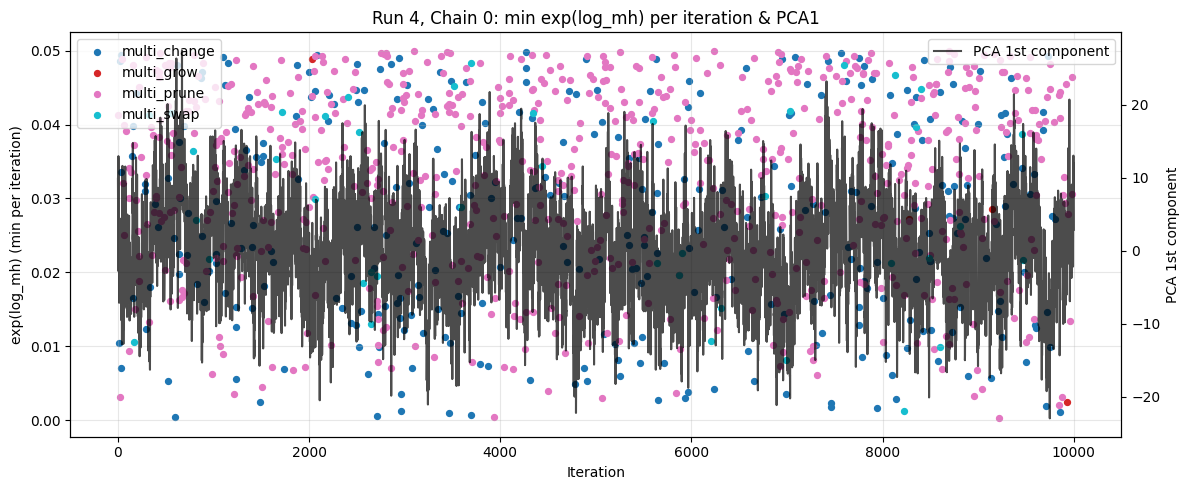

In [9]:
accepted_moves_logmh = mtmh_data['accepted_moves_logmh']
preds = mtmh_data['preds']

plot_moves_and_pca(
    accepted_moves_logmh,
    preds,
    threshold=0.05,
    agg_method='min',
    n_components=5,
    chain_id=0
)

# KPSS Test

## Preds (PCA)

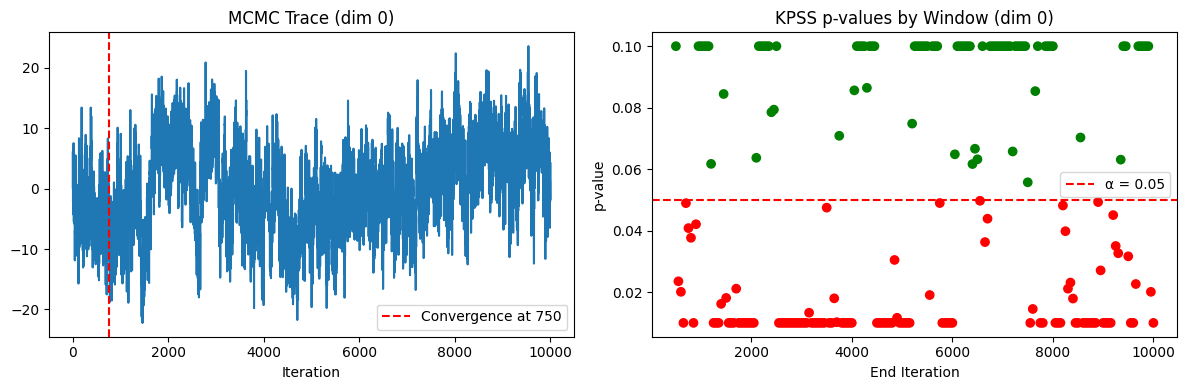

Run 0: convergence_iter = 750


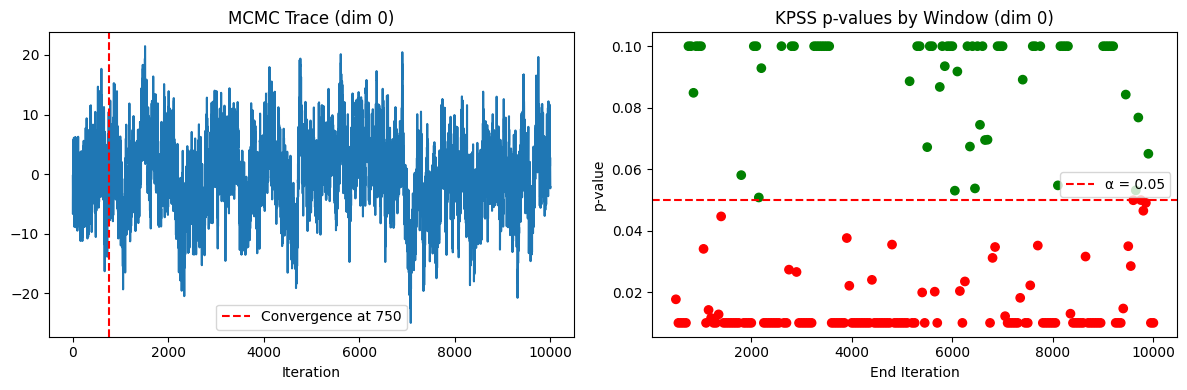

Run 1: convergence_iter = 750


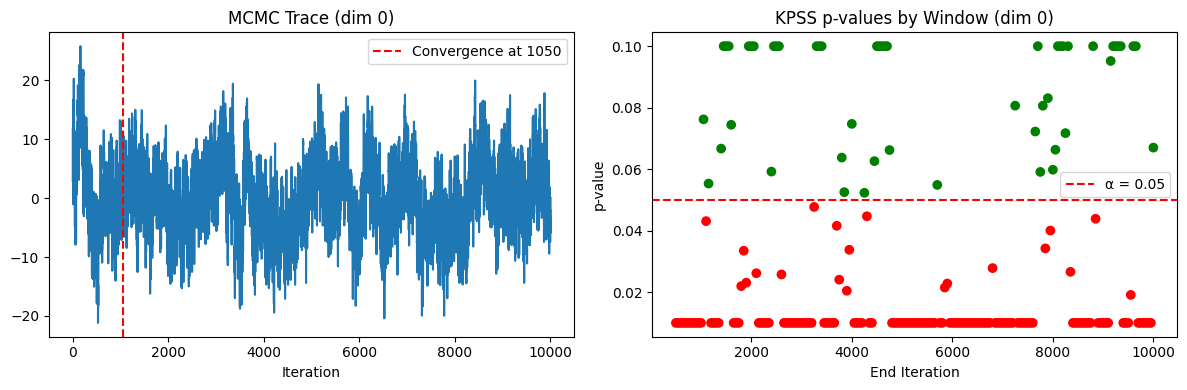

Run 2: convergence_iter = 1050


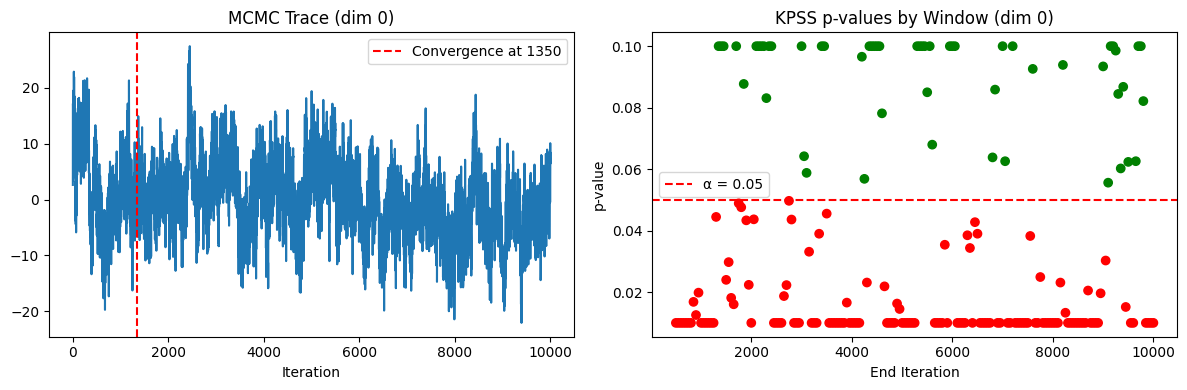

Run 3: convergence_iter = 1350


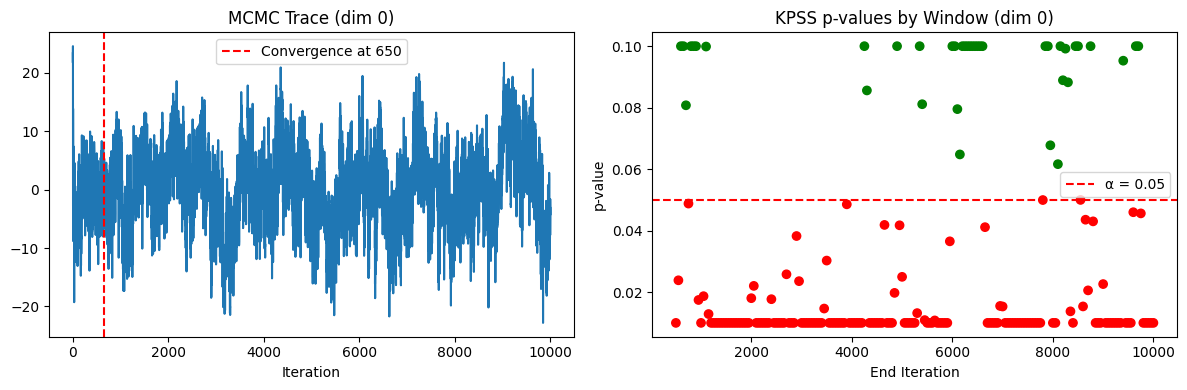

Run 4: convergence_iter = 650
All runs convergence_iter: [750, 750, 1050, 1350, 650]


In [10]:
import numpy as np
from diagnosis import segmented_kpss_test
from sklearn.decomposition import PCA

# default
preds = experiment_results['default'].item()['preds']  # shape: [n_runs, n_chains, n_test_points, n_iter]
n_runs, n_chains, n_test_points, n_iter = preds.shape

window_size = 500
step = 50
alpha = 0.05

convergence_iters = []
for run_id in range(n_runs):
    # shape: [n_test_points, n_iter]
    chain_preds = preds[run_id, 0].T  # [n_iter, n_test_points]
    chain_preds_centered = chain_preds - np.mean(chain_preds, axis=0)
    pca = PCA(n_components=5)
    chain_preds_pca = pca.fit_transform(chain_preds_centered)
    result = segmented_kpss_test(chain_preds_pca, window_size=window_size, step=step, alpha=alpha)
    convergence_iters.append(result['convergence_iteration'])
    print(f"Run {run_id}: convergence_iter = {result['convergence_iteration']}")

print("All runs convergence_iter:", convergence_iters)

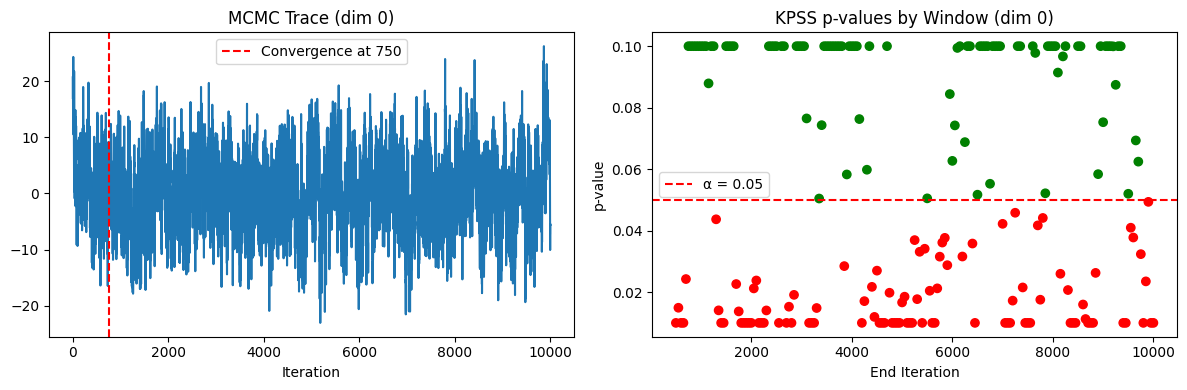

Run 0: convergence_iter = 750


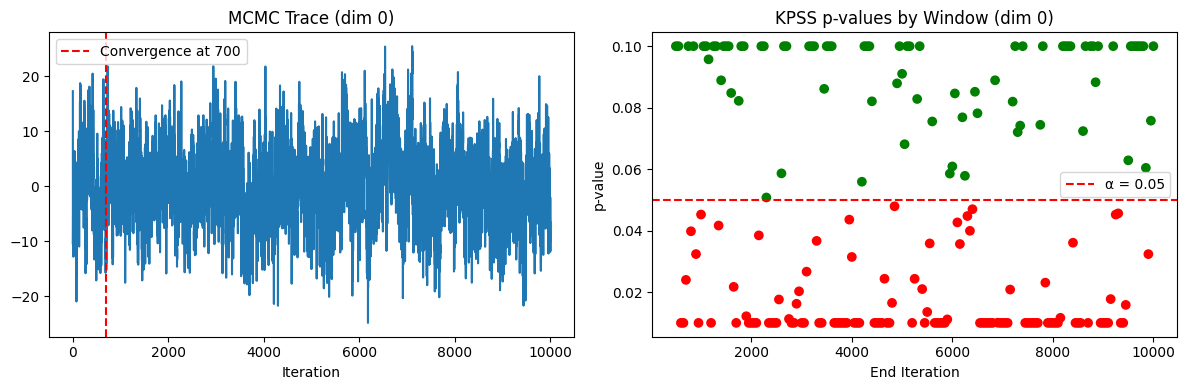

Run 1: convergence_iter = 700


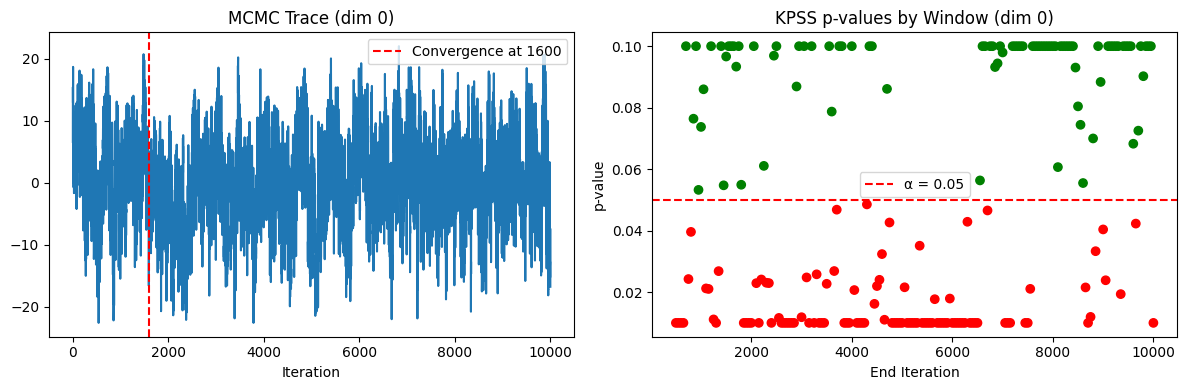

Run 2: convergence_iter = 1600


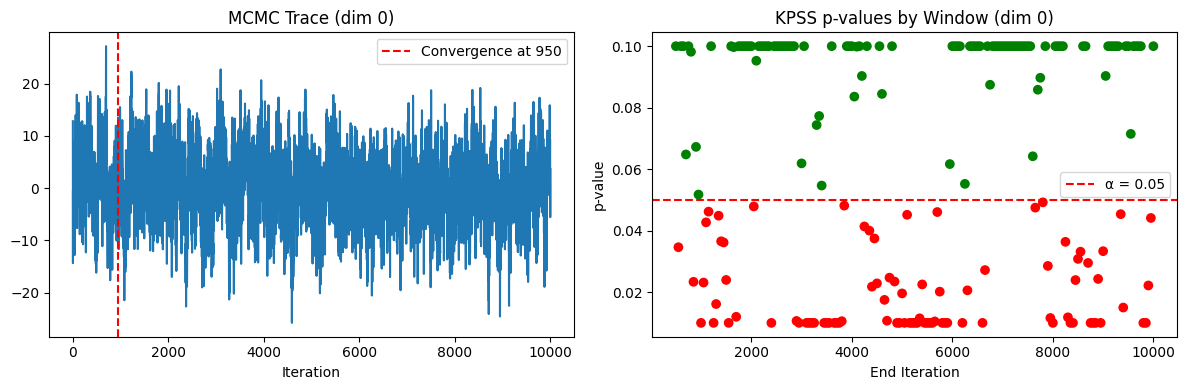

Run 3: convergence_iter = 950


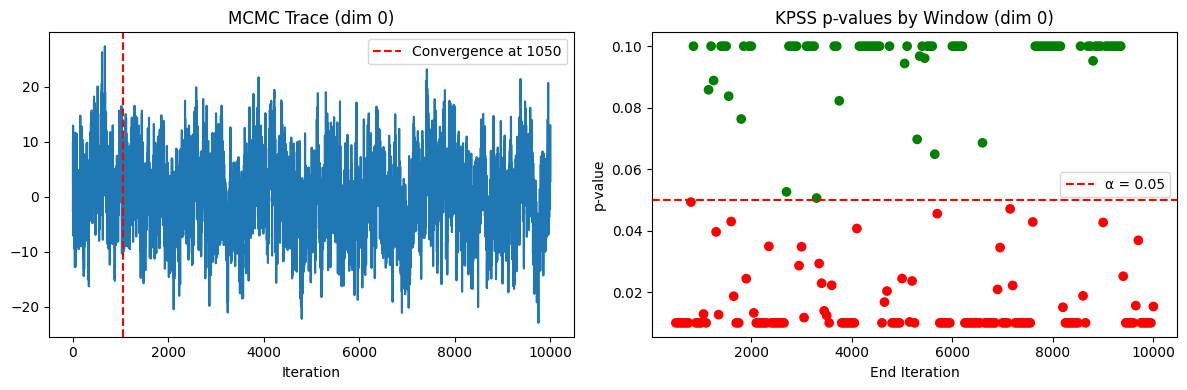

Run 4: convergence_iter = 1050
All runs convergence_iter: [750, 700, 1600, 950, 1050]


In [11]:
import numpy as np
from diagnosis import segmented_kpss_test
from sklearn.decomposition import PCA

# mtmh
preds = experiment_results['mtmh'].item()['preds']  # shape: [n_runs, n_chains, n_test_points, n_iter]
n_runs, n_chains, n_test_points, n_iter = preds.shape

window_size = 500
step = 50
alpha = 0.05

convergence_iters = []
for run_id in range(n_runs):
    # shape: [n_test_points, n_iter]
    chain_preds = preds[run_id, 0].T  # [n_iter, n_test_points]
    chain_preds_centered = chain_preds - np.mean(chain_preds, axis=0)
    pca = PCA(n_components=5)
    chain_preds_pca = pca.fit_transform(chain_preds_centered)
    result = segmented_kpss_test(chain_preds_pca, window_size=window_size, step=step, alpha=alpha)
    convergence_iters.append(result['convergence_iteration'])
    print(f"Run {run_id}: convergence_iter = {result['convergence_iteration']}")

print("All runs convergence_iter:", convergence_iters)

# Rhat (preds)

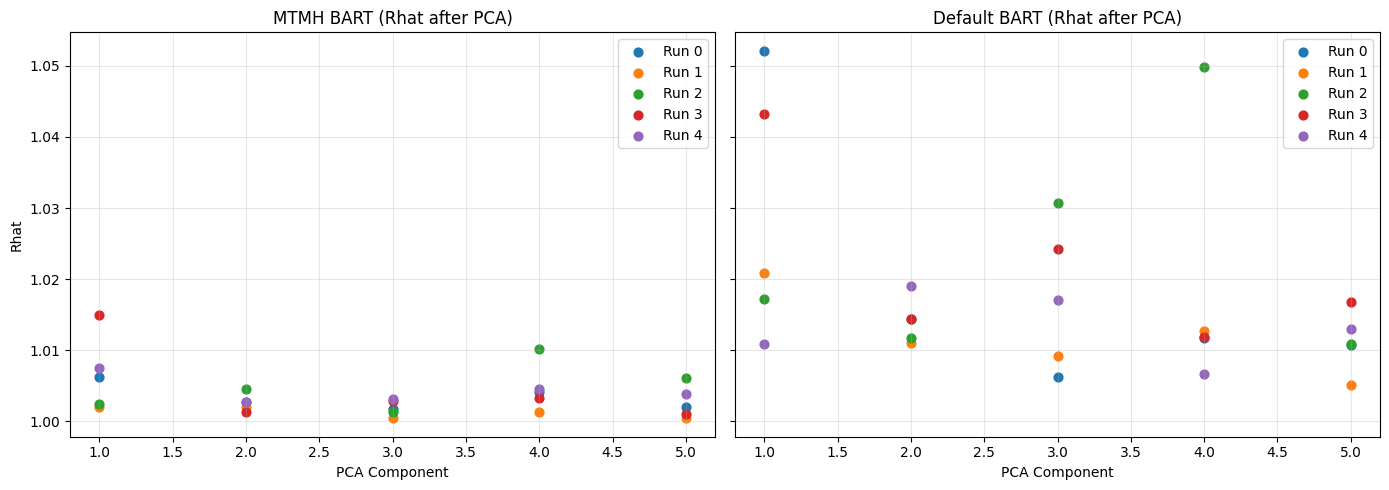

In [12]:
import numpy as np
import arviz as az
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def compute_rhat_pca_per_run(preds, n_components=5):
    n_runs, n_chains, n_test_points, n_iter = preds.shape
    rhat_all = []
    for run_id in range(n_runs):
        # [n_chains, n_test_points, n_iter] -> [n_chains, n_iter, n_test_points]
        x = preds[run_id, :, :, 3000:]
        x = np.transpose(x, (0, 2, 1))
        # Do PCA for each chain
        pca = PCA(n_components=n_components)
        z = np.array([pca.fit_transform(x_chain) for x_chain in x])  # [n_chains, n_iter, n_components]
        rhat_run = []
        for k in range(n_components):
            # z[:, :, k]: [n_chains, n_iter] for component k
            rhat_val = az.rhat(z[:, :, k])
            rhat_run.append(rhat_val)
        rhat_all.append(rhat_run)
    return np.array(rhat_all)  # [n_runs, n_components]

# Compute Rhat after PCA for default and mtmh
preds_default = experiment_results['default'].item()['preds']
preds_mtmh = experiment_results['mtmh'].item()['preds']

rhat_default_pca = compute_rhat_pca_per_run(preds_default)
rhat_mtmh_pca = compute_rhat_pca_per_run(preds_mtmh)
n_runs, n_components = rhat_default_pca.shape

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Left: MTMH
for run_id in range(n_runs):
    axes[0].scatter(np.arange(1, n_components+1), rhat_mtmh_pca[run_id], label=f'Run {run_id}', s=40)
axes[0].set_xlabel('PCA Component')
axes[0].set_ylabel('Rhat')
axes[0].set_title('MTMH BART (Rhat after PCA)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: Default
for run_id in range(n_runs):
    axes[1].scatter(np.arange(1, n_components+1), rhat_default_pca[run_id], label=f'Run {run_id}', s=40)
axes[1].set_xlabel('PCA Component')
axes[1].set_title('Default BART (Rhat after PCA)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ESS (preds)

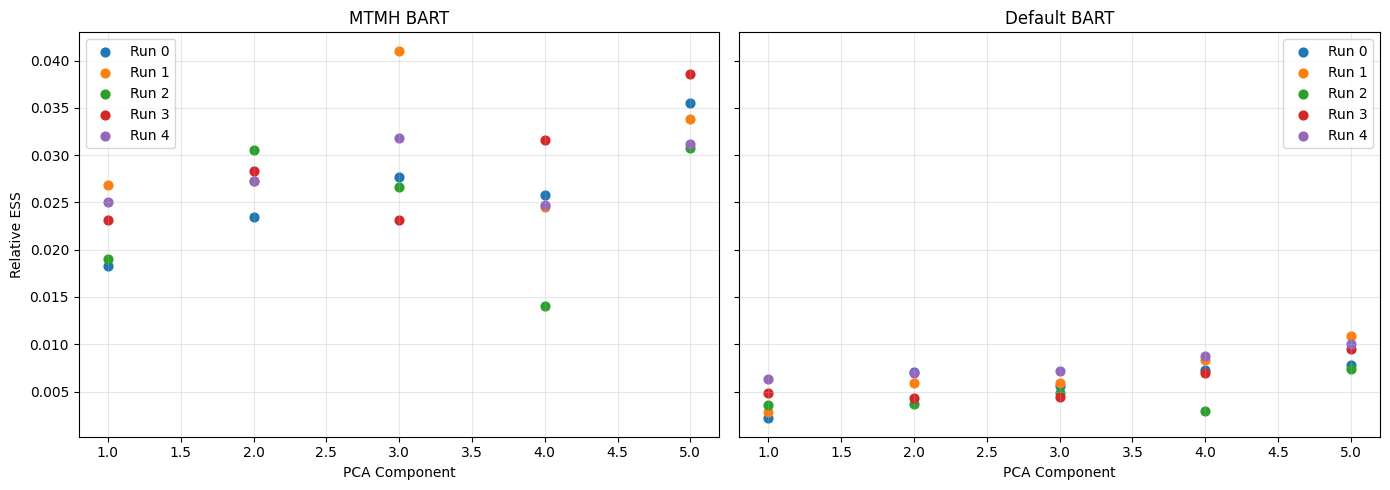

In [13]:
import numpy as np
from arviz.stats import ess
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def compute_ess_per_run(preds):
    n_runs, n_chains, n_test_points, n_iter = preds.shape
    ess_all = []
    for run_id in range(n_runs):
        x = preds[run_id, :, :, 3000:]  # [n_chains, n_test_points, n_iter]
        x = np.transpose(x, (0, 2, 1))  # [n_chains, n_iter, n_test_points]
        pca = PCA(n_components=5)
        z = np.array([pca.fit_transform(x_chain) for x_chain in x])  # [n_chains, n_iter, 5]
        ess_run = []
        for k in range(z.shape[2]):
            ess_val = ess(z[:, :, k], relative=True)
            ess_run.append(ess_val)
        ess_all.append(ess_run)
    return np.array(ess_all)  # [n_runs, 5]

# Compute ESS for default and mtmh
preds_default = experiment_results['default'].item()['preds']
preds_mtmh = experiment_results['mtmh'].item()['preds']

ess_default = compute_ess_per_run(preds_default)
ess_mtmh = compute_ess_per_run(preds_mtmh)

n_runs, n_components = ess_default.shape

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Left: MTMH
for run_id in range(n_runs):
    axes[0].scatter(np.arange(1, n_components+1), ess_mtmh[run_id], label=f'Run {run_id}', s=40)
axes[0].set_xlabel('PCA Component')
axes[0].set_ylabel('Relative ESS')
axes[0].set_title('MTMH BART')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: Default
for run_id in range(n_runs):
    axes[1].scatter(np.arange(1, n_components+1), ess_default[run_id], label=f'Run {run_id}', s=40)
axes[1].set_xlabel('PCA Component')
axes[1].set_title('Default BART')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Autocorrelation Plot (preds)

=== Default BART Analysis ===

--- Run 0 ---
Default PCA first component autocorrelation plot:


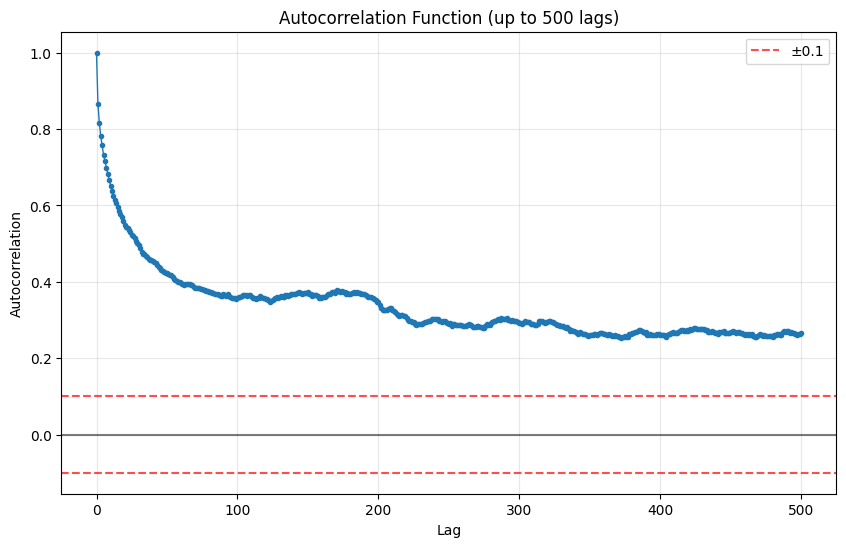


--- Run 1 ---
Default PCA first component autocorrelation plot:


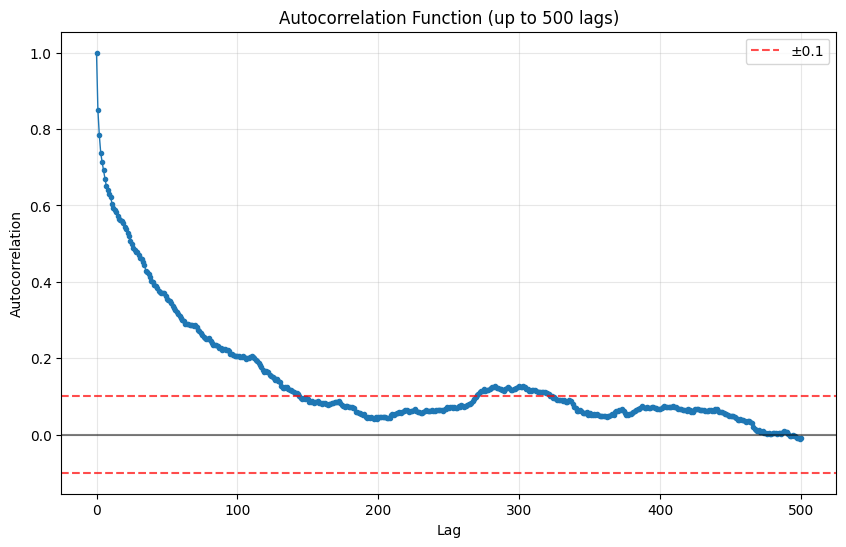


--- Run 2 ---
Default PCA first component autocorrelation plot:


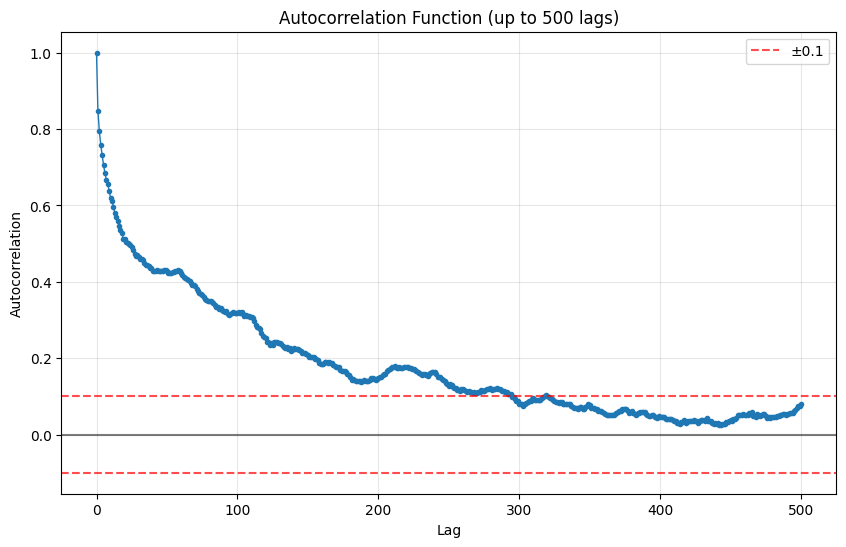


--- Run 3 ---
Default PCA first component autocorrelation plot:


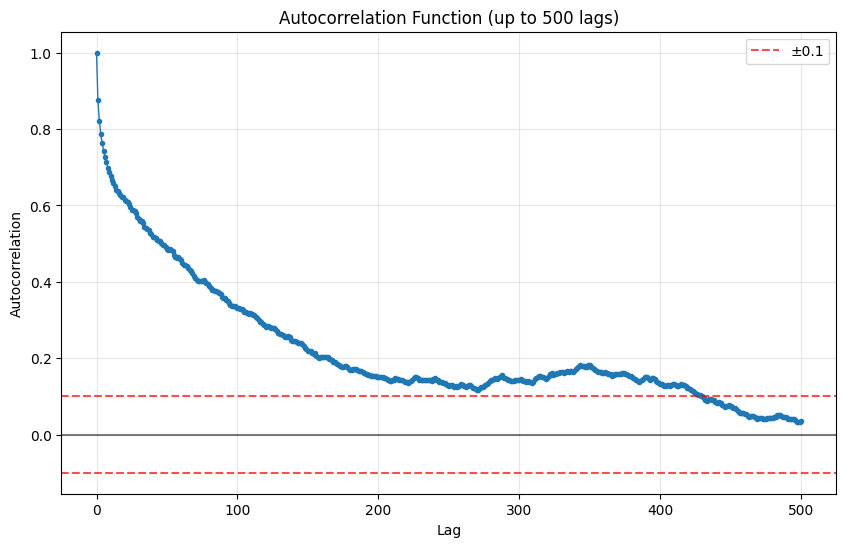


--- Run 4 ---
Default PCA first component autocorrelation plot:


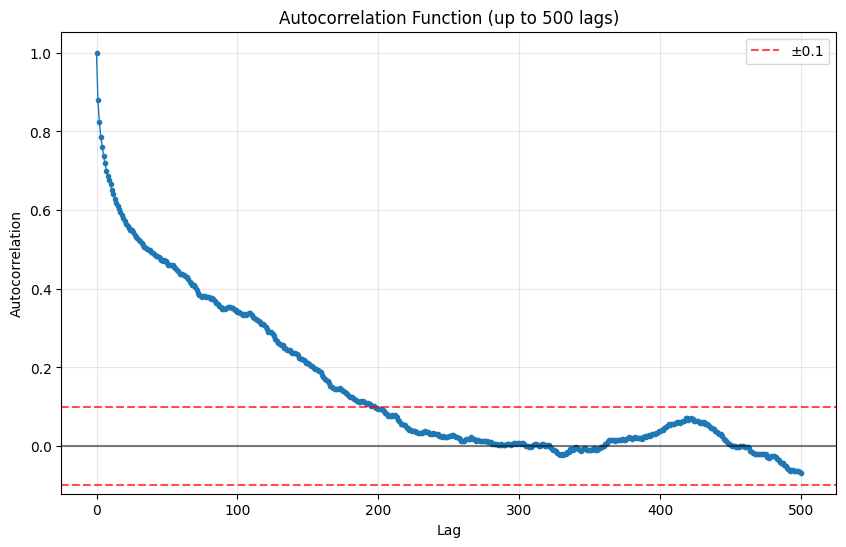

In [14]:
from diagnosis import plot_autocorrelation
from sklearn.decomposition import PCA
# Analyze each run's results
n_runs = 5

# Analyze Default BART results
print("=== Default BART Analysis ===")
for run_id in range(n_runs):
    print(f"\n--- Run {run_id} ---")
    
    # Extract data for this run
    preds = experiment_results['default'].item()['preds'][run_id, 0, :, 3000:]  # [n_test_points, n_iter]
    pred0 = preds[0, :]  # First test point
    x = np.transpose(preds, (1, 0))  # [n_iter, n_test_points]
    pca = PCA(n_components=5)
    z = pca.fit_transform(x)  # [n_iter, n_components]
    pca0 = z[:, 0]  # First PCA component

    # print(f"Default first pred autocorrelation plot:")
    # plot_autocorrelation(pred0, nlags=500)

    print(f"Default PCA first component autocorrelation plot:")
    plot_autocorrelation(pca0, nlags=500)

=== MTMH BART Analysis ===

--- Run 0 ---
MTMH PCA first component autocorrelation plot:


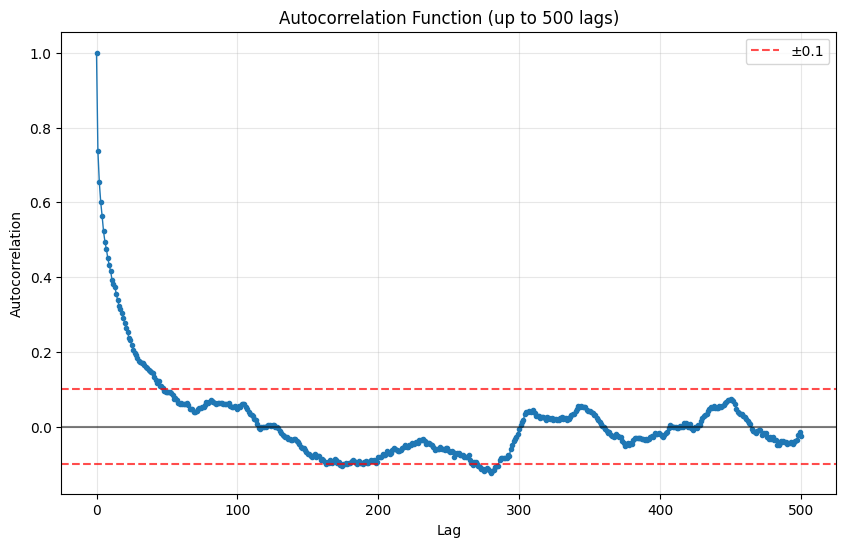


--- Run 1 ---
MTMH PCA first component autocorrelation plot:


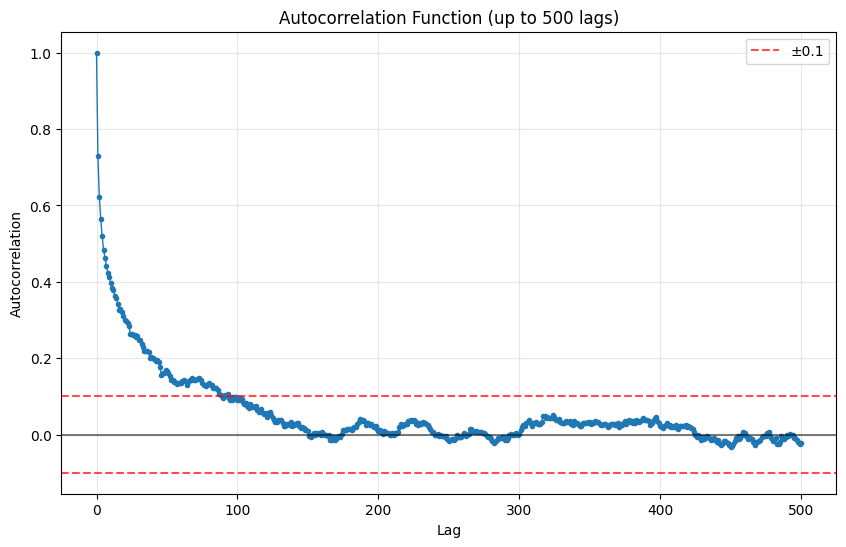


--- Run 2 ---
MTMH PCA first component autocorrelation plot:


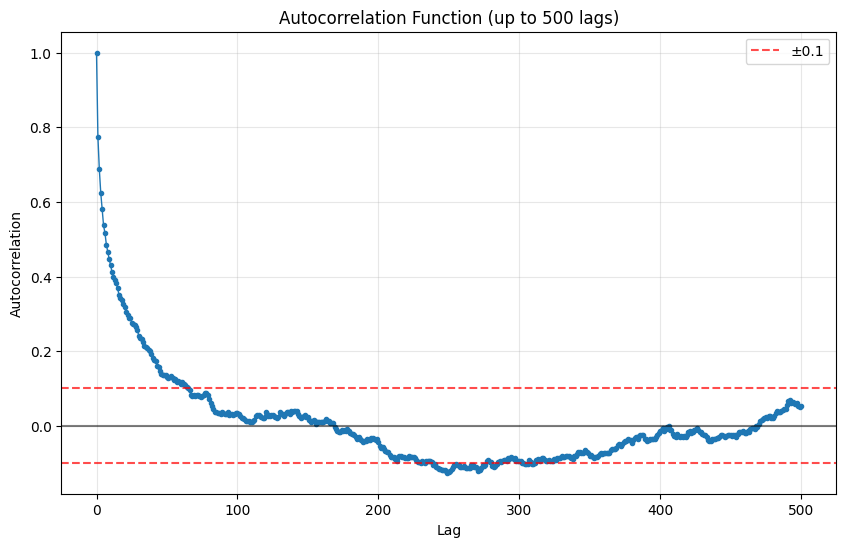


--- Run 3 ---
MTMH PCA first component autocorrelation plot:


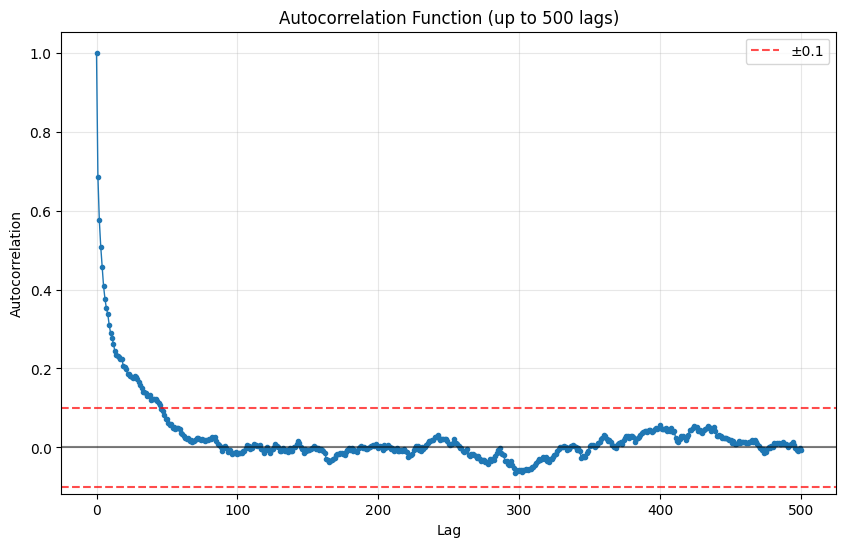


--- Run 4 ---
MTMH PCA first component autocorrelation plot:


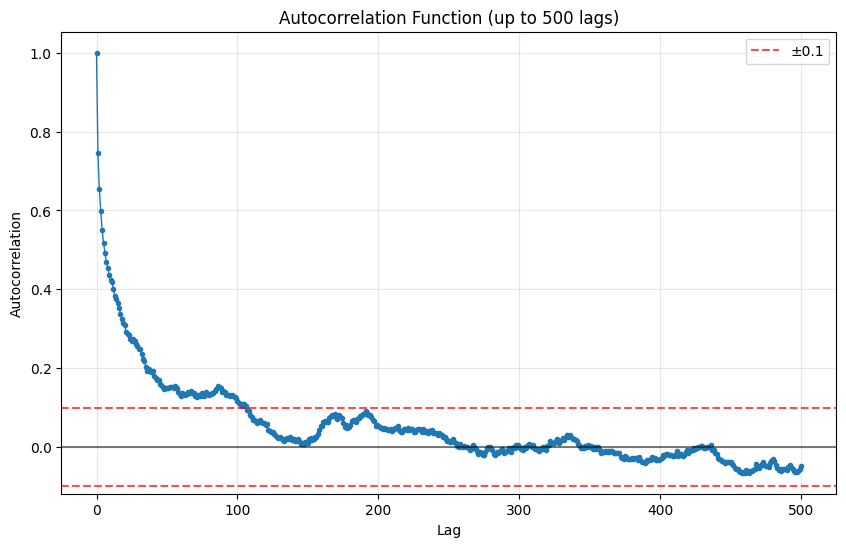

In [15]:
from diagnosis import plot_autocorrelation
from sklearn.decomposition import PCA
# Analyze each run's results
n_runs = 5

# Analyze MTMH BART results
print("=== MTMH BART Analysis ===")
for run_id in range(n_runs):
    print(f"\n--- Run {run_id} ---")
    
    # Extract data for this run
    preds = experiment_results['mtmh'].item()['preds'][run_id, 0, :, 3000:]  # [n_test_points, n_iter]
    pred0 = preds[0, :]  # First test point
    x = np.transpose(preds, (1, 0))  # [n_iter, n_test_points]
    pca = PCA(n_components=5)
    z = pca.fit_transform(x)  # [n_iter, n_components]
    pca0 = z[:, 0]  # First PCA component

    # print(f"MTMH first pred autocorrelation plot:")
    # plot_autocorrelation(pred0, nlags=500)

    print(f"MTMH PCA first component autocorrelation plot:")
    plot_autocorrelation(pca0, nlags=500)

# PCA Loadings

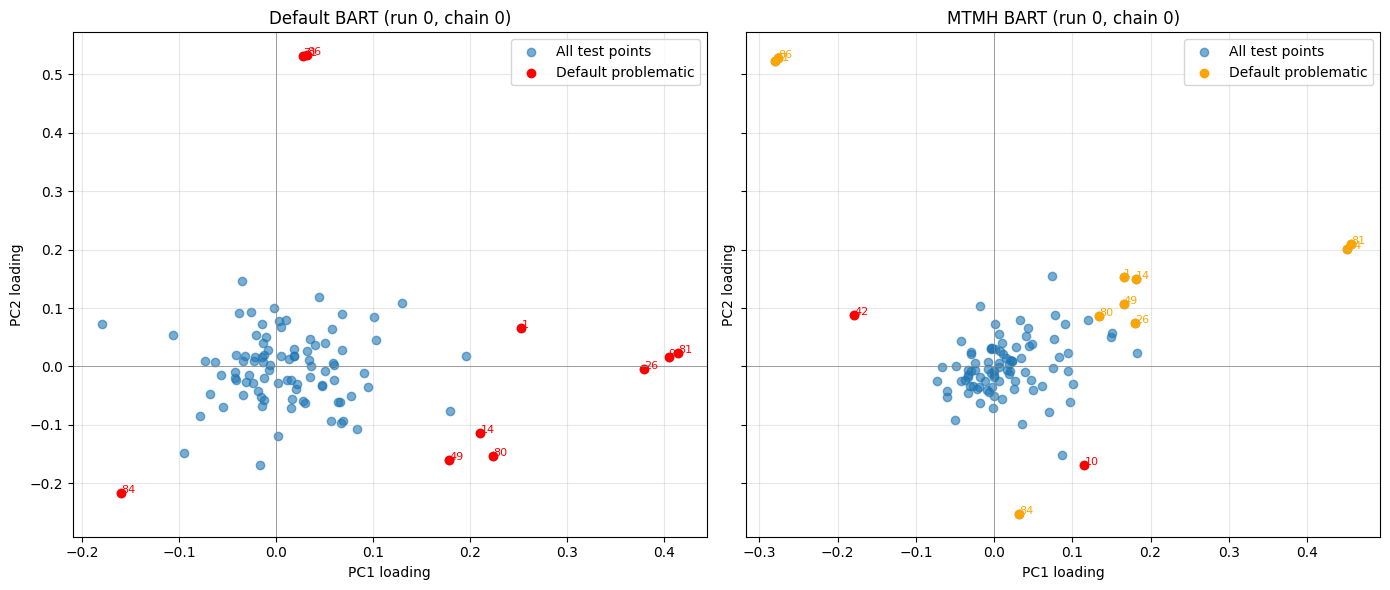

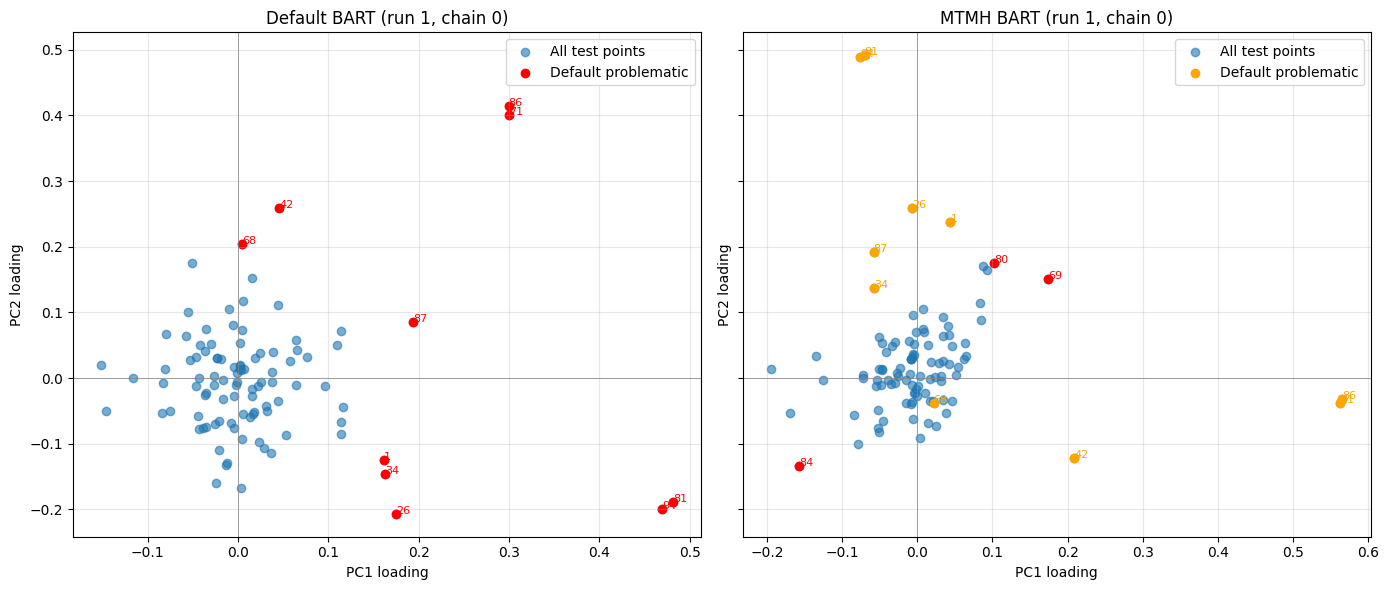

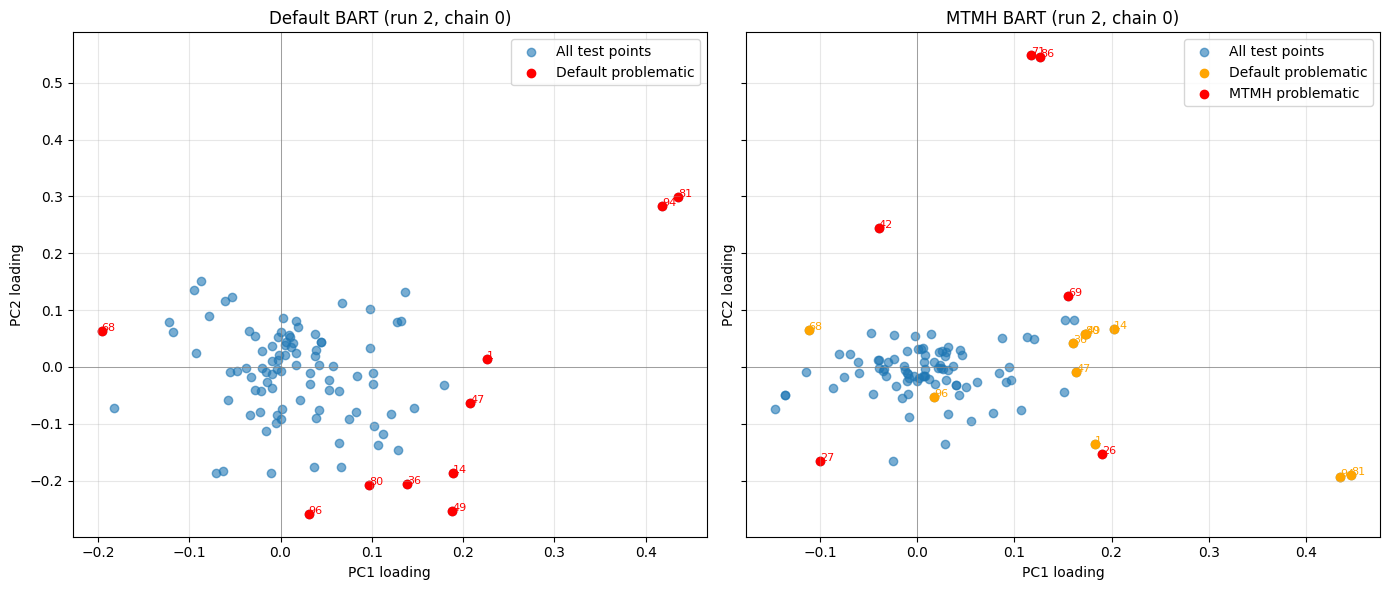

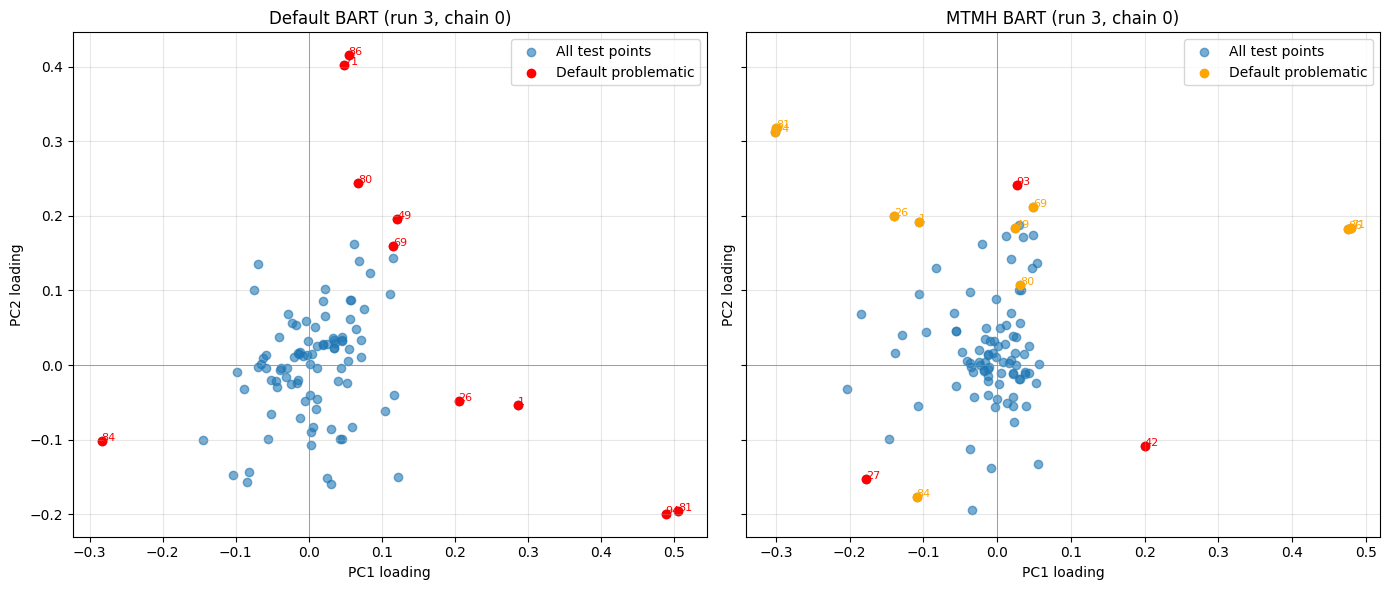

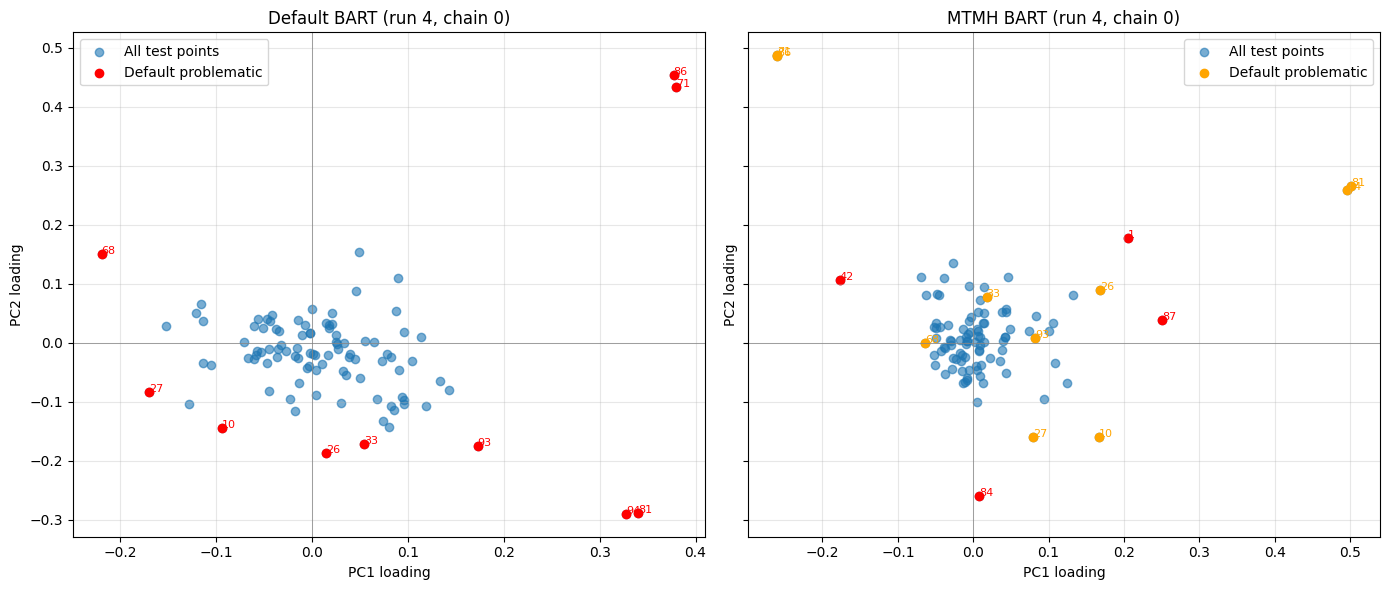

In [16]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Settings
burnin = 3000          # discard first iterations
n_components = 5       # PCA components to keep
n_pcs_for_score = 2    # how many leading PCs to use when scoring test points
top_k = 10             # how many most problematic test points to report

# Get preds for both methods
preds_default = experiment_results['default'].item()['preds']  # [n_runs, n_chains, n_test_points, n_iter]
preds_mtmh = experiment_results['mtmh'].item()['preds']

n_runs, n_chains, n_test_points, n_iter = preds_default.shape

# Store problematic indices for both methods
all_problematic_indices_default = []
all_problematic_indices_mtmh = []

for method, preds, all_problematic_indices in zip(
    ['default', 'mtmh'], [preds_default, preds_mtmh], [all_problematic_indices_default, all_problematic_indices_mtmh]
    ):
    for run_id in range(n_runs):
        chain_preds = preds[run_id, 0, :, burnin:]  # [n_test_points, n_iter]
        Z = chain_preds.T  # [n_iter_eff, n_test_points]
        pca = PCA(n_components=n_components)
        _ = pca.fit_transform(Z)
        loadings = pca.components_             # shape: [n_components, n_test_points]
        used_loadings = loadings[:n_pcs_for_score, :]        # [n_pcs_for_score, n_test_points]
        point_scores = np.sum(used_loadings ** 2, axis=0)    # [n_test_points]
        sorted_idx = np.argsort(point_scores)[::-1]
        all_problematic_indices.append(sorted_idx[:top_k])

# Plot for each run: left=default, right=mtmh
for run_id in range(n_runs):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    # For this run, get the problematic indices in default
    default_problematic = all_problematic_indices_default[run_id]
    mtmh_problematic = all_problematic_indices_mtmh[run_id]

    for ax, method, preds, all_problematic_indices, title in zip(
        axes,
        ['default', 'mtmh'],
        [preds_default, preds_mtmh],
        [all_problematic_indices_default, all_problematic_indices_mtmh],
        ['Default BART', 'MTMH BART']
    ):
        chain_preds_plot = preds[run_id, 0, :, burnin:]   # [n_test_points, n_iter]
        X_plot = chain_preds_plot.T
        X_plot_centered = X_plot - X_plot.mean(axis=0)
        pca_plot = PCA(n_components=n_components)
        _ = pca_plot.fit_transform(X_plot_centered)
        loadings_2d = pca_plot.components_[:2, :]  # first two PCs: [2, n_test_points]

        # Plot all test points
        ax.scatter(loadings_2d[0, :], loadings_2d[1, :], alpha=0.6, label="All test points")

        # Highlight problematic points for this run
        if method == 'default':
            for idx in default_problematic:
                ax.scatter(loadings_2d[0, idx], loadings_2d[1, idx], color="red", label="Default problematic" if idx == default_problematic[0] else None)
                ax.text(loadings_2d[0, idx], loadings_2d[1, idx], str(idx), color="red", fontsize=8)
        else:
            # In mtmh, mark the same problematic points as in default with orange
            for i, idx in enumerate(default_problematic):
                ax.scatter(loadings_2d[0, idx], loadings_2d[1, idx], color="orange", label="Default problematic" if i == 0 else None)
                ax.text(loadings_2d[0, idx], loadings_2d[1, idx], str(idx), color="orange", fontsize=8)
            # Also mark mtmh's own problematic points in red (not overlapping with default)
            for i, idx in enumerate(mtmh_problematic):
                if idx not in default_problematic:
                    ax.scatter(loadings_2d[0, idx], loadings_2d[1, idx], color="red", label="MTMH problematic" if i == 0 else None)
                    ax.text(loadings_2d[0, idx], loadings_2d[1, idx], str(idx), color="red", fontsize=8)

        ax.axhline(0, color="gray", linewidth=0.5)
        ax.axvline(0, color="gray", linewidth=0.5)
        ax.set_xlabel("PC1 loading")
        ax.set_ylabel("PC2 loading")
        ax.set_title(f"{title} (run {run_id}, chain 0)")
        ax.grid(alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()

# Credible Interval

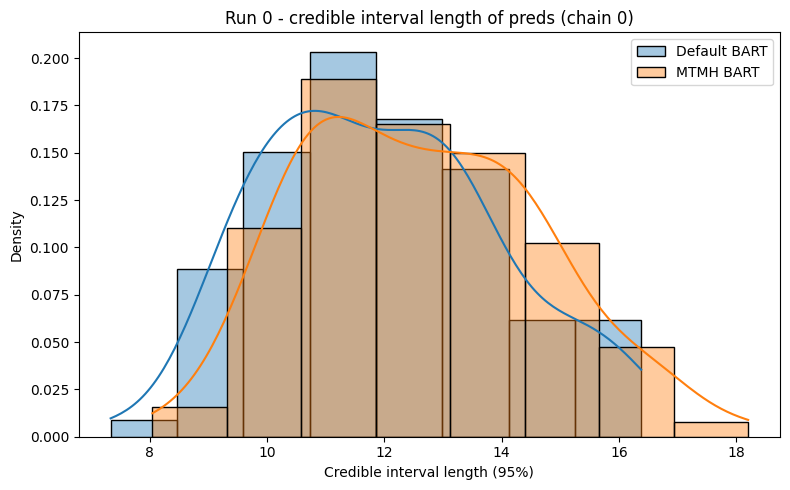

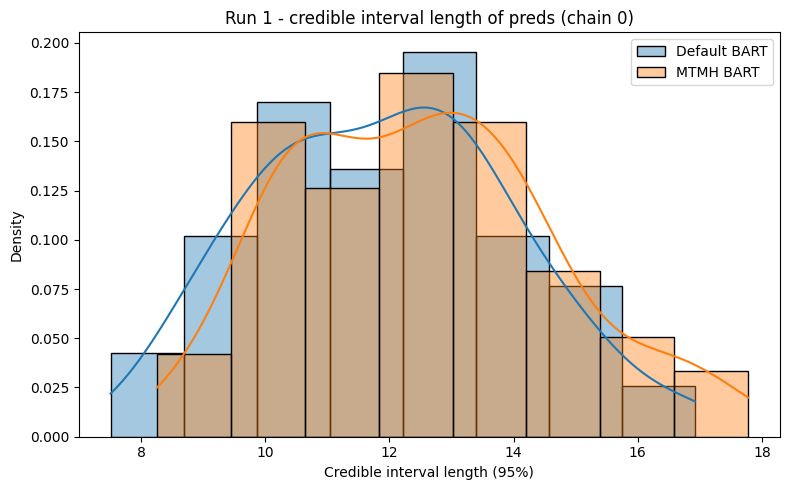

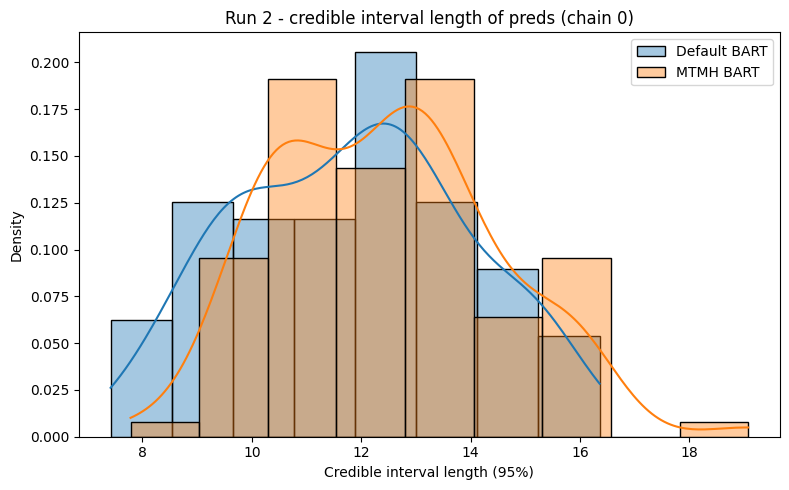

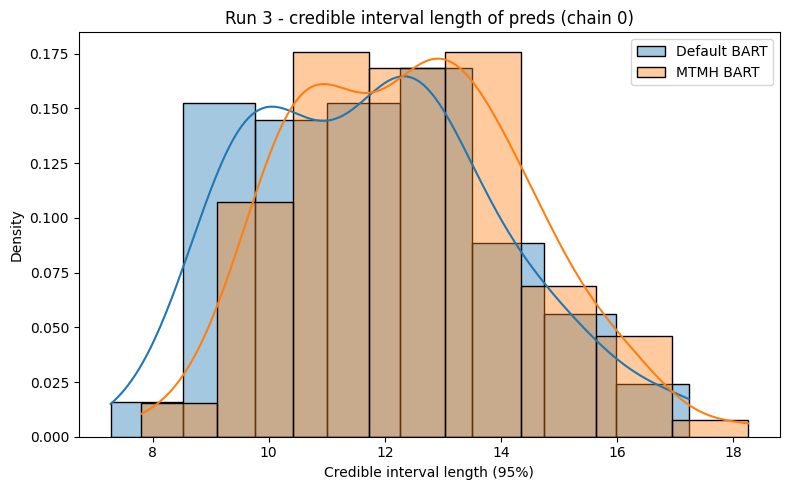

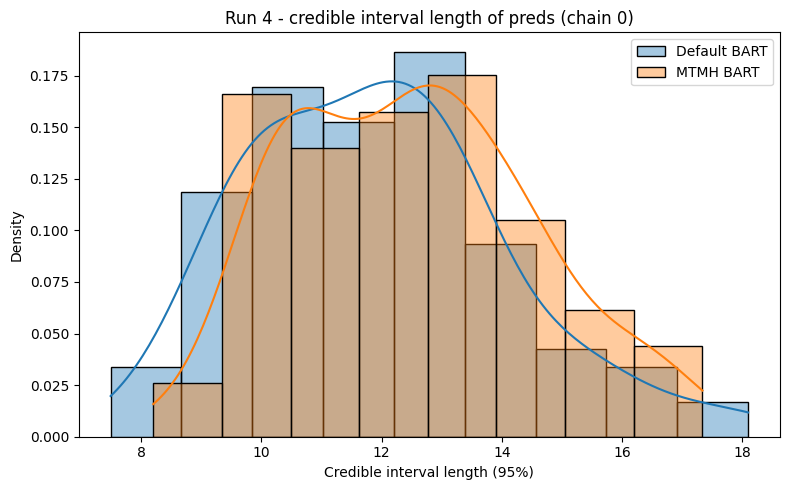

In [17]:
# Credible interval length of preds per test point (run-wise, chain 0)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# preds has shape: [n_runs, n_chains, n_test_points, n_iter]
preds_default = default_data["preds"]
preds_mtmh = mtmh_data["preds"]

n_runs, n_chains, n_test_points, n_iter = preds_default.shape

chain_id = 0  # use the first chain for all runs
lower_q, upper_q = 2.5, 97.5  # 95% credible interval

for run_id in range(n_runs):
    # Predictions for this run and the first chain
    chain_default = preds_default[run_id, chain_id][:, burnin:]  # [n_test_points, n_iter]
    chain_mtmh = preds_mtmh[run_id, chain_id][:, burnin:]        # [n_test_points, n_iter]

    # Credible interval length per test point
    lower_default = np.percentile(chain_default, lower_q, axis=1)
    upper_default = np.percentile(chain_default, upper_q, axis=1)
    ci_length_default = upper_default - lower_default

    lower_mtmh = np.percentile(chain_mtmh, lower_q, axis=1)
    upper_mtmh = np.percentile(chain_mtmh, upper_q, axis=1)
    ci_length_mtmh = upper_mtmh - lower_mtmh

    plt.figure(figsize=(8, 5))
    # Histogram + KDE for default BART
    sns.histplot(ci_length_default, kde=True, stat="density", color="tab:blue", alpha=0.4, label="Default BART")
    # Histogram + KDE for MTMH BART
    sns.histplot(ci_length_mtmh, kde=True, stat="density", color="tab:orange", alpha=0.4, label="MTMH BART")
    plt.xlabel("Credible interval length (95%)")
    plt.ylabel("Density")
    plt.title(f"Run {run_id} - credible interval length of preds (chain 0)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Continuous Ranked Probability Score (CRPS)

$$
\mathrm{CRPS}(F, y)
=
\mathbb{E}_F |X - y|
-
\frac{1}{2}\mathbb{E}_F |X - X'|,
\quad X, X' \sim F \ \text{i.i.d.}
$$


### Empirical CRPS (Samples $x_1,\dots,x_n$)

$$
\mathrm{CRPS}_n(y)
=
\frac{1}{n}\sum_{i=1}^n |x_i - y|
-
\frac{1}{2n^2}\sum_{i=1}^n\sum_{j=1}^n |x_i - x_j|
$$


### Fast Equivalent (Sorted Samples)

Let $x_{(1)} \le \cdots \le x_{(n)}$. Then

$$
\sum_{i,j}|x_i - x_j|
=
2\sum_{k=1}^n (2k - n - 1)\,x_{(k)}
$$

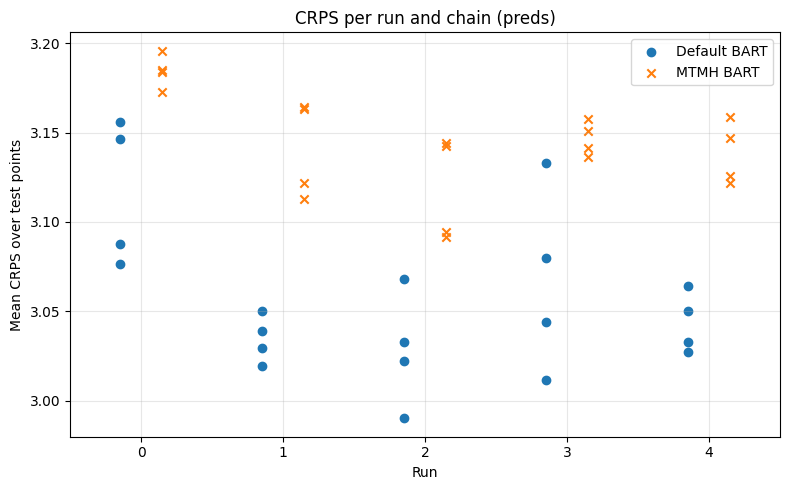

In [18]:
# CRPS comparison between default and MTMH (per run and per chain, using preds)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# preds shape: [n_runs, n_chains, n_test_points, n_iter]
preds_default = default_data["preds"]
preds_mtmh = mtmh_data["preds"]
n_runs, n_chains, n_test_points, n_iter = preds_default.shape

# Reconstruct y_test exactly as in run_experiment
X_train, X_test, y_train, y_test_full = train_test_split(X, y, random_state=42)
if n_test_points < X_test.shape[0]:
    rng = np.random.default_rng(42)  # same seed as in experiment_init.py
    idx = rng.choice(X_test.shape[0], n_test_points, replace=False)
    y_test = y_test_full[idx]
else:
    y_test = y_test_full

def crps_from_samples_fast(samples, y_true):
    """
    samples: [n_points, n_samples]
    y_true:  [n_points]
    returns: [n_points]
    """
    n = samples.shape[1]

    # term1: E|X - y|
    term1 = np.mean(np.abs(samples - y_true[:, None]), axis=1)

    # term2: 0.5 * E|X - X'|  (fast version)
    xs = np.sort(samples, axis=1)  # [n_points, n_samples]

    k = np.arange(1, n + 1)         # 1,...,n
    weights = (2 * k - n - 1)       # shape [n]

    # broadcasting: [n_points, n_samples] * [n_samples]
    term2 = np.sum(xs * weights, axis=1) / (n * n)

    return term1 - term2

# CRPS per run and per chain
crps_default = np.zeros((n_runs, n_chains))
crps_mtmh = np.zeros((n_runs, n_chains))

for run_id in range(n_runs):
    for chain_id in range(n_chains):
        s_def = preds_default[run_id, chain_id][:, burnin:]   # [n_test_points, n_iter]
        s_m   = preds_mtmh[run_id, chain_id][:, burnin:]
        crps_default[run_id, chain_id] = crps_from_samples_fast(s_def, y_test).mean()
        crps_mtmh[run_id, chain_id]    = crps_from_samples_fast(s_m, y_test).mean()

# One figure: x-axis = runs, points = chains
runs = np.arange(n_runs)
plt.figure(figsize=(8, 5))

first_default = True
first_mtmh = True

for run_id in range(n_runs):
    for chain_id in range(n_chains):
        # Shift default points to the left, MTMH points to the right within each run
        x_def = run_id - 0.15
        x_m   = run_id + 0.15

        plt.scatter(
            x_def,
            crps_default[run_id, chain_id],
            color="tab:blue",
            marker="o",
            label="Default BART" if first_default else None,
        )
        plt.scatter(
            x_m,
            crps_mtmh[run_id, chain_id],
            color="tab:orange",
            marker="x",
            label="MTMH BART" if first_mtmh else None,
        )

        first_default = False
        first_mtmh = False

plt.xlabel("Run")
plt.ylabel("Mean CRPS over test points")
plt.title("CRPS per run and chain (preds)")
plt.xticks(runs, [f"{r}" for r in runs])
plt.xlim(-0.5, n_runs - 0.5)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Multimodality

## Single run, difference chains (with same initialization)

Average pairwise distance between chain centroids (default, run 0): 0.9141


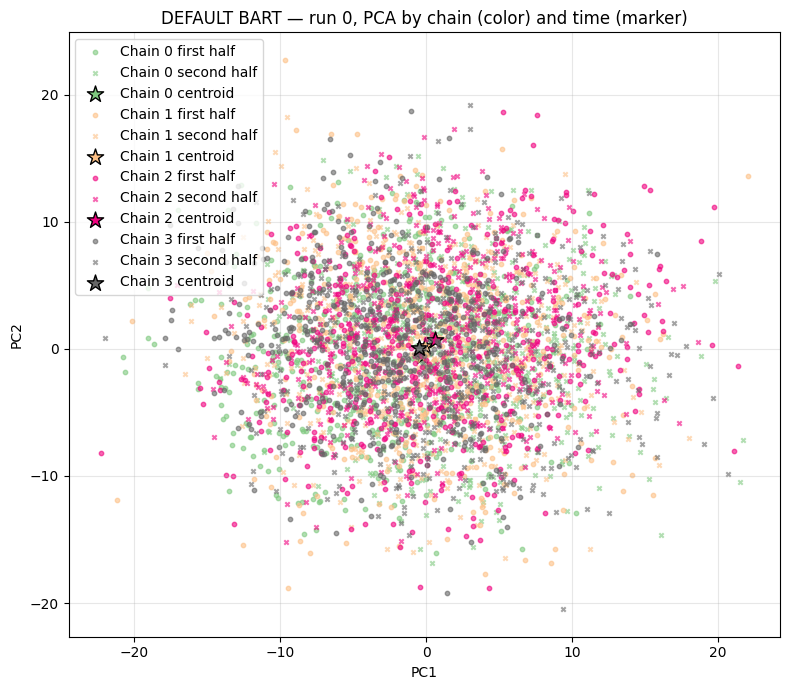

Average pairwise distance between chain centroids (mtmh, run 0): 0.2720


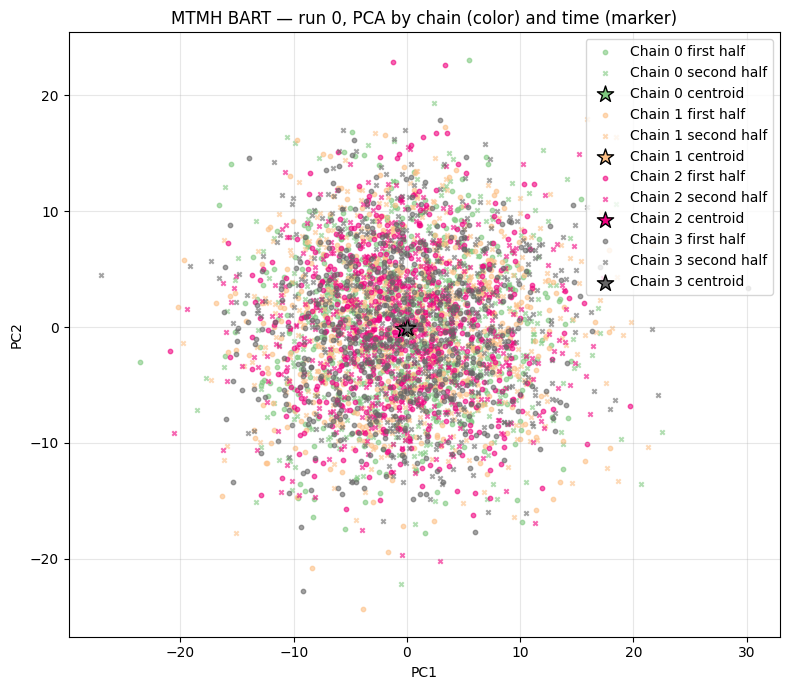

In [19]:
# Multimodality: PCA scatter of chains for a single run
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def scatter_pca_by_chain(experiment_results,
                         which='default',
                         run_id=0,
                         burnin=3000,
                         n_components=2,
                         max_points=1000):
    """
    Plot PC1-PC2 scatter for all chains in a given run.

    - Color: different chains
    - Marker: first half vs second half of iterations (after burn-in)
    - Centroid: star marker for each chain's centroid in PC space
    """
    data = experiment_results[which].item()
    preds = data['preds']  # [n_runs, n_chains, n_test_points, n_iter]
    _, n_chains, _, n_iter = preds.shape

    if burnin >= n_iter:
        raise ValueError(f"burnin ({burnin}) must be < n_iter ({n_iter})")

    # Merge all chains after burn-in, and label first/second half in time
    X_list = []
    chain_labels = []
    segment_labels = []  # 0: first half, 1: second half

    n_iter_eff = n_iter - burnin
    mid = burnin + n_iter_eff // 2  # split point in original iteration index

    for c in range(n_chains):
        # [n_test_points, n_iter_eff] -> [n_iter_eff, n_test_points]
        X = preds[run_id, c, :, burnin:].T  # [n_iter_eff, n_test_points]
        if X.shape[0] == 0:
            continue
        Xc = X  # no additional centering here
        X_list.append(Xc)

        # local iteration indices after burnin
        iters_global = np.arange(burnin, n_iter)  # length n_iter_eff
        seg_c = np.where(iters_global < mid, 0, 1)  # 0: first half, 1: second half
        chain_labels.extend([c] * Xc.shape[0])
        segment_labels.extend(seg_c.tolist())

    if not X_list:
        raise ValueError("No iterations left after burn-in; check burnin and n_iter")

    X_merged = np.vstack(X_list)  # [n_chains * n_iter_eff, n_test_points]
    chain_labels = np.array(chain_labels)
    segment_labels = np.array(segment_labels)

    # PCA
    pca = PCA(n_components=n_components)
    Z = pca.fit_transform(X_merged)  # [total_points, n_components]

    # Subsample
    if max_points is not None and Z.shape[0] > max_points * n_chains:
        step = int(np.ceil(Z.shape[0] / (max_points * n_chains)))
        Z_plot = Z[::step]
        chain_labels_plot = chain_labels[::step]
        segment_labels_plot = segment_labels[::step]
    else:
        Z_plot = Z
        chain_labels_plot = chain_labels
        segment_labels_plot = segment_labels

    colors = plt.get_cmap("Accent", n_chains).colors
    markers = ["o", "x"]  # 0: first half, 1: second half

    plt.figure(figsize=(8, 7))
    centroids = []
    centroid_chain_ids = []

    for c in range(n_chains):
        for seg in [0, 1]:
            idx = (chain_labels_plot == c) & (segment_labels_plot == seg)
            if not np.any(idx):
                continue
            label = (f"Chain {c} first half" if seg == 0
                     else f"Chain {c} second half")
            plt.scatter(Z_plot[idx, 0], Z_plot[idx, 1],
                        s=10, alpha=0.6, color=colors[c], marker=markers[seg],
                        label=label)

        # draw centroid for this chain (over all its points)
        idx_chain = (chain_labels_plot == c)
        if np.any(idx_chain):
            centroid = Z_plot[idx_chain].mean(axis=0)
            centroids.append(centroid)
            centroid_chain_ids.append(c)
            plt.scatter(centroid[0], centroid[1],
                        s=150, marker='*', color=colors[c], edgecolor='black',
                        label=f"Chain {c} centroid")

    # summarize pairwise distances between chain centroids with a single scalar
    if len(centroids) > 1:
        C = np.vstack(centroids)  # [n_centroids, 2]
        diff = C[:, None, :] - C[None, :, :]  # [n_centroids, n_centroids, 2]
        D = np.sqrt(np.sum(diff**2, axis=-1))  # pairwise Euclidean distances
        i, j = np.triu_indices(len(centroids), k=1)
        pairwise_dists = D[i, j]
        avg_dist = pairwise_dists.mean()
        print(f"Average pairwise distance between chain centroids ({which}, run {run_id}): {avg_dist:.4f}")
    else:
        print("Not enough centroids to compute pairwise distance between chains.")

    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title(f'{which.upper()} BART — run {run_id}, PCA by chain (color) and time (marker)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Usage for run_id=0:
# Default BART
scatter_pca_by_chain(experiment_results, which='default', run_id=0, burnin=3000)

# MTMH BART
scatter_pca_by_chain(experiment_results, which='mtmh', run_id=0, burnin=3000)

## Different runs (different initializaions)

Average pairwise distance between run centroids (default): 1.9195


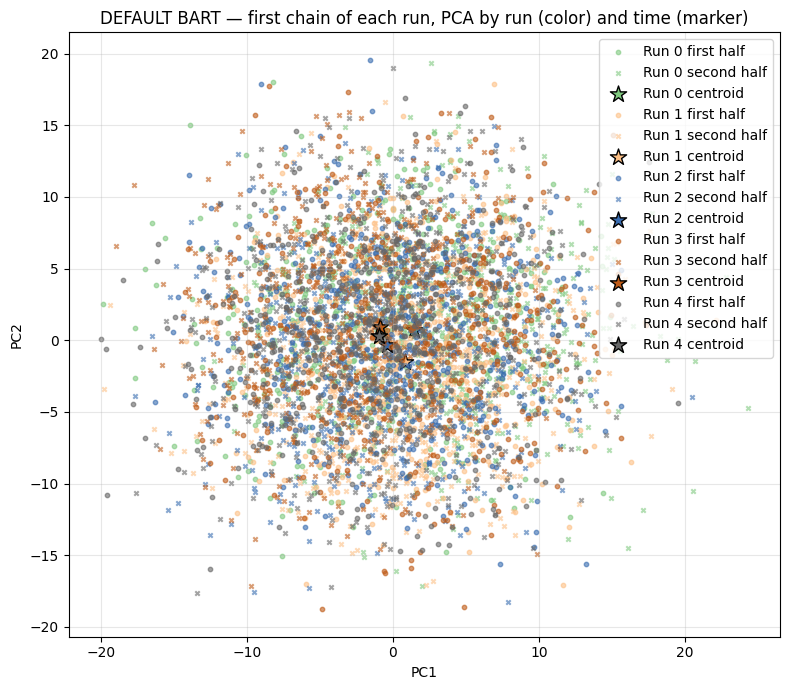

Average pairwise distance between run centroids (mtmh): 1.1600


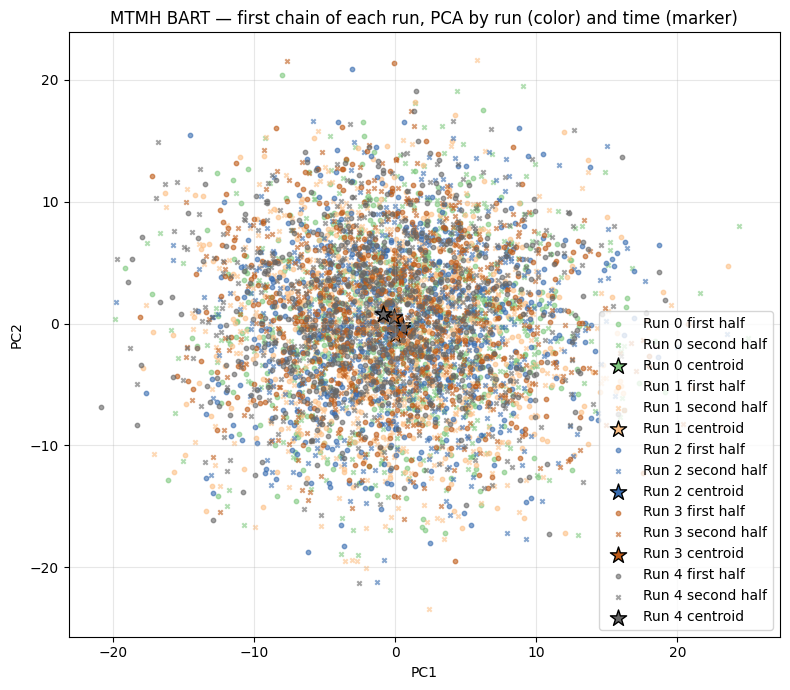

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

def scatter_pca_by_run(experiment_results,
                       which='default',
                       burnin=3000,
                       n_components=2,
                       max_points=1000):
    """
    Merge the first chain of each run after burn-in, perform PCA on the merged data.

    - Color: different runs
    - Marker: first half vs second half of iterations (after burn-in)
    - Centroid: star marker for each run's centroid in PC space
    """
    data = experiment_results[which].item()
    preds = data['preds']  # [n_runs, n_chains, n_test_points, n_iter]
    n_runs, n_chains, _, n_iter = preds.shape

    if burnin >= n_iter:
        raise ValueError(f"burnin ({burnin}) must be < n_iter ({n_iter})")

    n_iter_eff = n_iter - burnin
    mid = burnin + n_iter_eff // 2  # split point in original iteration index

    # Collect all first chains after burn-in and label first/second half
    X_list = []
    run_labels = []
    segment_labels = []  # 0: first half, 1: second half
    iters_global = np.arange(burnin, n_iter)  # common for all runs
    seg_global = np.where(iters_global < mid, 0, 1)

    for run_id in range(n_runs):
        X = preds[run_id, 0, :, burnin:].T  # [n_iter_eff, n_test_points]
        if X.shape[0] == 0:
            continue
        Xc = X  # no additional centering here
        X_list.append(Xc)

        run_labels.extend([run_id] * Xc.shape[0])
        segment_labels.extend(seg_global.tolist())

    if not X_list:
        raise ValueError("No iterations left after burn-in; check burnin and n_iter")

    X_merged = np.vstack(X_list)  # [n_runs * n_iter_eff, n_test_points]
    run_labels = np.array(run_labels)
    segment_labels = np.array(segment_labels)

    # PCA on merged data
    pca = PCA(n_components=n_components)
    Z = pca.fit_transform(X_merged)  # [total_points, n_components]

    # Optional subsampling for plotting clarity
    if max_points is not None and Z.shape[0] > max_points * n_runs:
        step = int(np.ceil(Z.shape[0] / (max_points * n_runs)))
        Z_plot = Z[::step]
        run_labels_plot = run_labels[::step]
        segment_labels_plot = segment_labels[::step]
    else:
        Z_plot = Z
        run_labels_plot = run_labels
        segment_labels_plot = segment_labels

    colors = plt.get_cmap("Accent", n_runs).colors
    markers = ["o", "x"]  # 0: first half, 1: second half

    plt.figure(figsize=(8, 7))
    centroids = []
    centroid_run_ids = []

    for run_id in range(n_runs):
        for seg in [0, 1]:
            idx = (run_labels_plot == run_id) & (segment_labels_plot == seg)
            if not np.any(idx):
                continue
            label = (f"Run {run_id} first half" if seg == 0
                     else f"Run {run_id} second half")
            plt.scatter(Z_plot[idx, 0], Z_plot[idx, 1],
                        s=10, alpha=0.6, color=colors[run_id], marker=markers[seg],
                        label=label)

        # draw centroid for this run (over all its points)
        idx_run = (run_labels_plot == run_id)
        if np.any(idx_run):
            centroid = Z_plot[idx_run].mean(axis=0)
            centroids.append(centroid)
            centroid_run_ids.append(run_id)
            plt.scatter(centroid[0], centroid[1],
                        s=150, marker='*', color=colors[run_id], edgecolor='black',
                        label=f"Run {run_id} centroid")

    # summarize pairwise distances between run centroids with a single scalar
    if len(centroids) > 1:
        C = np.vstack(centroids)  # [n_centroids, 2]
        diff = C[:, None, :] - C[None, :, :]  # [n_centroids, n_centroids, 2]
        D = np.sqrt(np.sum(diff**2, axis=-1))  # pairwise Euclidean distances
        i, j = np.triu_indices(len(centroids), k=1)
        pairwise_dists = D[i, j]
        avg_dist = pairwise_dists.mean()
        print(f"Average pairwise distance between run centroids ({which}): {avg_dist:.4f}")
    else:
        print("Not enough centroids to compute pairwise distance between runs.")

    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title(f'{which.upper()} BART — first chain of each run, PCA by run (color) and time (marker)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Example usage:
scatter_pca_by_run(experiment_results, which='default', burnin=3000)
scatter_pca_by_run(experiment_results, which='mtmh', burnin=3000)

In [21]:
# PCA on all runs and chains after burn-in, then centroid distance statistics

import numpy as np
from sklearn.decomposition import PCA

def compute_pca_centroid_distances(preds, burnin=3000, n_components=2):
    """
    preds: array of shape [n_runs, n_chains, n_test_points, n_iter]
    burnin: number of initial iterations to discard
    n_components: PCA components to keep
    """
    n_runs, n_chains, n_test_points, n_iter = preds.shape
    if burnin >= n_iter:
        raise ValueError(f"burnin ({burnin}) must be < n_iter ({n_iter})")

    # Collect all (run, chain) draws after burn-in
    X_list = []
    run_labels = []
    chain_labels = []

    for r in range(n_runs):
        for c in range(n_chains):
            # [n_test_points, n_iter_eff] -> [n_iter_eff, n_test_points]
            X_rc = preds[r, c, :, burnin:].T
            if X_rc.shape[0] == 0:
                continue
            X_list.append(X_rc)
            run_labels.extend([r] * X_rc.shape[0])
            chain_labels.extend([c] * X_rc.shape[0])

    if not X_list:
        raise ValueError("No iterations left after burn-in; check burnin and n_iter")

    X_merged = np.vstack(X_list)          # [total_points, n_test_points]
    run_labels = np.array(run_labels)     # [total_points]
    chain_labels = np.array(chain_labels) # [total_points]

    # PCA on merged data
    pca = PCA(n_components=n_components)
    Z = pca.fit_transform(X_merged)       # [total_points, n_components]

    # Centroid per (run, chain)
    centroids = np.full((n_runs, n_chains, n_components), np.nan, dtype=float)
    for r in range(n_runs):
        for c in range(n_chains):
            idx = (run_labels == r) & (chain_labels == c)
            if not np.any(idx):
                continue
            centroids[r, c, :] = Z[idx].mean(axis=0)

    # 1) For each run: average centroid distance between chains in that run
    avg_chain_dists_per_run = np.full(n_runs, np.nan, dtype=float)
    for r in range(n_runs):
        valid = ~np.isnan(centroids[r, :, 0])
        chain_ids = np.where(valid)[0]
        if chain_ids.size < 2:
            continue
        C = centroids[r, chain_ids, :]  # [n_valid_chains, n_components]
        diff = C[:, None, :] - C[None, :, :]
        D = np.sqrt(np.sum(diff ** 2, axis=-1))
        i, j = np.triu_indices(C.shape[0], k=1)
        avg_chain_dists_per_run[r] = D[i, j].mean()

    # 2) For each chain_id: average centroid distance between runs for that chain_id
    avg_run_dists_per_chain = np.full(n_chains, np.nan, dtype=float)
    for c in range(n_chains):
        valid = ~np.isnan(centroids[:, c, 0])
        run_ids = np.where(valid)[0]
        if run_ids.size < 2:
            continue
        C = centroids[run_ids, c, :]  # [n_valid_runs, n_components]
        diff = C[:, None, :] - C[None, :, :]
        D = np.sqrt(np.sum(diff ** 2, axis=-1))
        i, j = np.triu_indices(C.shape[0], k=1)
        avg_run_dists_per_chain[c] = D[i, j].mean()

    # 3) Overall average centroid distance between all different (run, chain) pairs
    valid_pairs = ~np.isnan(centroids[:, :, 0])
    C_all = centroids[valid_pairs]  # [n_pairs, n_components]
    if C_all.shape[0] >= 2:
        diff = C_all[:, None, :] - C_all[None, :, :]
        D = np.sqrt(np.sum(diff ** 2, axis=-1))
        i, j = np.triu_indices(C_all.shape[0], k=1)
        overall_avg_dist = D[i, j].mean()
    else:
        overall_avg_dist = np.nan

    return {
        "centroids": centroids,
        "avg_chain_dists_per_run": avg_chain_dists_per_run,
        "avg_run_dists_per_chain": avg_run_dists_per_chain,
        "overall_avg_dist": overall_avg_dist,
    }


# Example usage for default and MTMH BART
burnin = 3000  # make sure this matches the rest of your notebook

preds_default = experiment_results["default"].item()["preds"]
preds_mtmh = experiment_results["mtmh"].item()["preds"]

print("=== Default BART ===")
res_default = compute_pca_centroid_distances(preds_default, burnin=burnin, n_components=2)
print("Average centroid distance between chains within each run:")
for r, val in enumerate(res_default["avg_chain_dists_per_run"]):
    if np.isnan(val):
        print(f"  Run {r}: NaN (not enough chains with data)")
    else:
        print(f"  Run {r}: {val:.4f}")

print("\nAverage centroid distance between runs for each chain_id:")
for c, val in enumerate(res_default["avg_run_dists_per_chain"]):
    if np.isnan(val):
        print(f"  Chain {c}: NaN (not enough runs with data)")
    else:
        print(f"  Chain {c}: {val:.4f}")

print(f"\nOverall average centroid distance between all (run, chain) pairs: "
      f"{res_default['overall_avg_dist']:.4f}")

print("\n\n=== MTMH BART ===")
res_mtmh = compute_pca_centroid_distances(preds_mtmh, burnin=burnin, n_components=2)
print("Average centroid distance between chains within each run:")
for r, val in enumerate(res_mtmh["avg_chain_dists_per_run"]):
    if np.isnan(val):
        print(f"  Run {r}: NaN (not enough chains with data)")
    else:
        print(f"  Run {r}: {val:.4f}")

print("\nAverage centroid distance between runs for each chain_id:")
for c, val in enumerate(res_mtmh["avg_run_dists_per_chain"]):
    if np.isnan(val):
        print(f"  Chain {c}: NaN (not enough runs with data)")
    else:
        print(f"  Chain {c}: {val:.4f}")

print(f"\nOverall average centroid distance between all (run, chain) pairs: "
      f"{res_mtmh['overall_avg_dist']:.4f}")

=== Default BART ===
Average centroid distance between chains within each run:
  Run 0: 0.7172
  Run 1: 2.0895
  Run 2: 1.1383
  Run 3: 1.3721
  Run 4: 1.1523

Average centroid distance between runs for each chain_id:
  Chain 0: 1.8490
  Chain 1: 1.5386
  Chain 2: 2.1437
  Chain 3: 1.7589

Overall average centroid distance between all (run, chain) pairs: 1.7054


=== MTMH BART ===
Average centroid distance between chains within each run:
  Run 0: 0.3250
  Run 1: 0.8018
  Run 2: 0.2475
  Run 3: 0.8403
  Run 4: 1.0233

Average centroid distance between runs for each chain_id:
  Chain 0: 1.1048
  Chain 1: 0.5342
  Chain 2: 0.6057
  Chain 3: 0.7765

Overall average centroid distance between all (run, chain) pairs: 0.7206


# Coverage

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Boolean coverage arrays: shape [n_runs, n_chains, n_test_points]
default_coverage = default_data["coverage"]
mtmh_coverage = mtmh_data["coverage"]

# Mean coverage over test points for each run and each chain
default_coverage_mean = default_coverage.mean(axis=2)  # [n_runs, n_chains]
mtmh_coverage_mean = mtmh_coverage.mean(axis=2)        # [n_runs, n_chains]

n_runs, n_chains = default_coverage_mean.shape

print("=== Mean coverage (rows = chains, columns = runs) — Default BART ===")
header = "Chain/Run " + " ".join([f"Run{r}" for r in range(n_runs)])
print(header)
for chain_id in range(n_chains):
    row_vals = " ".join([f"{default_coverage_mean[run_id, chain_id]:.4f}" for run_id in range(n_runs)])
    print(f"Chain{chain_id}  {row_vals}")
default_run_mean = default_coverage_mean.mean(axis=1)  # [n_runs]
row_vals = " ".join([f"{default_run_mean[run_id]:.4f}" for run_id in range(n_runs)])
print(f"Mean      {row_vals}")

print("\n=== Mean coverage (rows = chains, columns = runs) — MTMH BART ===")
header = "Chain/Run " + " ".join([f"Run{r}" for r in range(n_runs)])
print(header)
for chain_id in range(n_chains):
    row_vals = " ".join([f"{mtmh_coverage_mean[run_id, chain_id]:.4f}" for run_id in range(n_runs)])
    print(f"Chain{chain_id}  {row_vals}")
mtmh_run_mean = mtmh_coverage_mean.mean(axis=1)  # [n_runs]
row_vals = " ".join([f"{mtmh_run_mean[run_id]:.4f}" for run_id in range(n_runs)])
print(f"Mean      {row_vals}")


=== Mean coverage (rows = chains, columns = runs) — Default BART ===
Chain/Run Run0 Run1 Run2 Run3 Run4
Chain0  0.9845 0.9845 0.9845 0.9806 0.9845
Chain1  0.9845 0.9845 0.9845 0.9806 0.9845
Chain2  0.9845 0.9845 0.9845 0.9806 0.9845
Chain3  0.9845 0.9845 0.9806 0.9845 0.9845
Mean      0.9845 0.9845 0.9835 0.9816 0.9845

=== Mean coverage (rows = chains, columns = runs) — MTMH BART ===
Chain/Run Run0 Run1 Run2 Run3 Run4
Chain0  0.9845 0.9845 0.9845 0.9845 0.9845
Chain1  0.9845 0.9845 0.9845 0.9845 0.9845
Chain2  0.9845 0.9845 0.9845 0.9845 0.9845
Chain3  0.9845 0.9845 0.9845 0.9845 0.9845
Mean      0.9845 0.9845 0.9845 0.9845 0.9845
